%pip install holidays

%pip install geopandas

In [3]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
users = pd.read_csv(r"C:\data_science\inpost_task\users.csv",sep=";",decimal=".")
session_geo = pd.read_csv(r"C:\data_science\inpost_task\session_geo.csv",sep=";",decimal=".")
session_info = pd.read_csv(r"C:\data_science\inpost_task\session_info.csv",sep=";",decimal=".")

In [5]:
users.head(10)

,user_id,education,car_flg,flat_flg,gender,salary,age,previous_purchases_flg,in_users_base_flg,number_of_previous_products
0,0,primary,0,1.0,0,8643.0,61.0,0,0,3.0
1,1,secondary,0,0.0,0,5537.0,44.0,0,1,11.0
2,2,primary,1,1.0,0,8985.0,50.0,0,1,39.0
3,3,secondary,1,0.0,0,5547.0,57.0,0,1,8.0
4,4,higher,0,0.0,1,9211.0,54.0,0,1,7.0
5,5,secondary,0,1.0,0,10004.0,63.0,0,1,9.0
6,6,higher,1,1.0,0,7748.0,44.0,0,1,10.0
7,7,secondary,0,1.0,1,9924.0,51.0,1,1,17.0
8,8,higher,1,1.0,1,9428.0,47.0,0,1,12.0
9,9,secondary,1,1.0,0,5320.0,59.0,1,1,1.0


In [6]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      6000 non-null   int64  
 1   education                    6000 non-null   str    
 2   car_flg                      6000 non-null   int64  
 3   flat_flg                     5910 non-null   float64
 4   gender                       6000 non-null   int64  
 5   salary                       5880 non-null   float64
 6   age                          5820 non-null   float64
 7   previous_purchases_flg       6000 non-null   int64  
 8   in_users_base_flg            6000 non-null   int64  
 9   number_of_previous_products  5520 non-null   float64
dtypes: float64(4), int64(5), str(1)
memory usage: 468.9 KB


In [7]:
users.describe()

,user_id,car_flg,flat_flg,gender,salary,age,previous_purchases_flg,in_users_base_flg,number_of_previous_products
count,6000.000000,6000.000000,5910.000000,6000.000000,5880.000000,5820.000000,6000.000000,6000.000000,5520.000000
mean,2999.500000,0.644000,0.520474,0.353333,8189.846088,50.873196,0.178000,0.794333,8.861413
std,1732.195139,0.478855,0.499623,0.478045,2069.266849,6.819833,0.382545,0.404222,5.619527
min,0.000000,0.000000,0.000000,0.000000,2100.000000,18.000000,0.000000,0.000000,0.000000
25%,1499.750000,0.000000,0.000000,0.000000,6677.500000,47.000000,0.000000,1.000000,6.000000
50%,2999.500000,1.000000,1.000000,0.000000,7793.000000,51.000000,0.000000,1.000000,9.000000
75%,4499.250000,1.000000,1.000000,1.000000,9546.500000,55.000000,0.000000,1.000000,11.000000
max,5999.000000,1.000000,1.000000,1.000000,16100.000000,73.000000,1.000000,1.000000,39.000000


In [8]:
session_geo.head(10)

,session_id,lon,lat
0,972387,20.408246,52.094380
1,384994,20.408145,52.018082
2,173981,20.432250,52.038129
3,144649,20.422656,52.076472
4,475443,20.363652,52.118518
5,309859,20.433421,52.075897
6,441499,20.433341,52.109335
7,815406,20.426250,52.070475
8,957153,20.449729,52.143308
9,215560,20.404503,52.167776


In [9]:
session_geo.info()

<class 'pandas.DataFrame'>
RangeIndex: 120375 entries, 0 to 120374
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   session_id  120375 non-null  int64  
 1   lon         120375 non-null  float64
 2   lat         120375 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 2.8 MB


In [10]:
session_geo.describe()

,session_id,lon,lat
count,120375.000000,120375.000000,120375.000000
mean,500401.801919,19.046808,51.639949
std,288681.826811,2.085614,1.388284
min,4.000000,14.126132,49.134679
25%,249955.000000,17.872439,50.310368
50%,501776.000000,18.980031,51.422219
75%,749668.500000,20.573762,52.697532
max,999996.000000,23.768234,54.875864


In [11]:
session_info.head(10)

,session_id,user_id,date,session_length_min
0,972387,0,2020-05-01 18:07:54,3.302053
1,384994,0,2020-04-14 13:31:19,0.274498
2,173981,0,2020-08-04 17:36:17,2.846373
3,144649,0,2020-04-14 09:54:36,1.009348
4,475443,0,2020-04-24 21:51:14,4.217949
5,309859,0,2020-04-26 09:56:34,4.798495
6,441499,0,2020-04-14 14:43:53,9.465938
7,815406,0,2020-06-11 19:29:20,3.706595
8,957153,0,0,5.858023
9,215560,0,2020-04-04 18:25:34,7.643954


In [12]:
session_info.info()

<class 'pandas.DataFrame'>
RangeIndex: 120375 entries, 0 to 120374
Data columns (total 4 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   session_id          120375 non-null  int64  
 1   user_id             120375 non-null  int64  
 2   date                116882 non-null  str    
 3   session_length_min  120375 non-null  float64
dtypes: float64(1), int64(2), str(1)
memory usage: 3.7 MB


In [13]:
session_info.describe()

,session_id,user_id,session_length_min
count,120375.000000,120375.000000,120375.000000
mean,500401.801919,3000.632299,11.388197
std,288681.826811,1736.776900,11.920745
min,4.000000,0.000000,0.000082
25%,249955.000000,1492.000000,3.171046
50%,501776.000000,3006.000000,7.690383
75%,749668.500000,4493.000000,15.553201
max,999996.000000,5999.000000,244.133561


In [ ]:
# source - https://dane.gov.pl/pl/dataset/780/resource/30102,panstwowy-rejestr-nazw-geograficznych-miejscowosci-format-xlsx/table
# Państwowy Rejestr Nazw Geograficznych (PRNG) - Rejestr nazw geograficznych RP - miejscowości - format XLSX

geo_names=pd.read_excel(r'C:\data_science\inpost_task\PRNG_MIEJSCOWOSCI_XLSX.xlsx')

In [15]:
geo_names[['nazwa główna','nazwa miejscowości nadrzędnej','współrzędne geograficzne']].head(5)

,nazwa główna,nazwa miejscowości nadrzędnej,współrzędne geograficzne
0,Osiedle Struga,Dzierżoniów,"50°43'05"" 16°39'17"""
1,Abisynia,Przydziałki,"51°53'15"" 17°49'23"""
2,Abisynia,Pławin,"52°49'34"" 15°39'12"""
3,Abisynia,Drawsko,"52°50'45"" 16°01'59"""
4,Abisynia,Krapkowice,"50°29'50"" 17°58'15"""


In [16]:
geo_names.info(40)

<class 'pandas.DataFrame'>
RangeIndex: 124261 entries, 0 to 124260
Data columns (total 39 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   identyfikator IIP                      124261 non-null  str    
 1   identyfikator PRNG                     124261 non-null  int64  
 2   nazwa główna                           124261 non-null  str    
 3   element rozróżniający                  124260 non-null  str    
 4   element rodzajowy                      5685 non-null    str    
 5   dopełniacz                             124260 non-null  str    
 6   przymiotnik                            44665 non-null   str    
 7   status nazwy                           124261 non-null  str    
 8   kategoria obiektu                      124261 non-null  str    
 9   rodzaj obiektu                         124261 non-null  str    
 10  nazwa miejscowości nadrzędnej          69539 non-null   str    
 11

In [61]:
geo_names_short=geo_names[['nazwa główna','nazwa miejscowości nadrzędnej','rodzaj obiektu','współrzędne geograficzne','województwo','powiat','gmina','identyfikator gminy']]

In [65]:
geo_names_short=geo_names_short.drop_duplicates()

In [ ]:
import re

def dms_pair_to_lon_lat(coord):
    
    # Convert classical degree geo coordinates into lon lat format.
    
    if pd.isna(coord):
        return pd.Series([None, None])

    pattern = r"(\d+)°\s*(\d+)'\s*(\d+(?:\.\d+)?)\""
    matches = re.findall(pattern, str(coord))

    if len(matches) != 2:
        return pd.Series([None, None])

    def convert(dms_tuple):
        degrees, minutes, seconds = map(float, dms_tuple)
        return degrees + minutes / 60 + seconds / 3600

    lat = convert(matches[0])
    lon = convert(matches[1])

    return pd.Series([lon, lat])

In [67]:
geo_names_short[["lon", "lat"]] = geo_names_short["współrzędne geograficzne"].apply(dms_pair_to_lon_lat)

In [68]:
geo_names_short.head(10)

,nazwa główna,nazwa miejscowości nadrzędnej,rodzaj obiektu,współrzędne geograficzne,województwo,powiat,gmina,identyfikator gminy,lon,lat
0,Osiedle Struga,Dzierżoniów,część miasta,"50°43'05"" 16°39'17""",dolnośląskie,dzierżoniowski,Dzierżoniów-gmina miejska,202021,16.654722,50.718056
1,Abisynia,Przydziałki,część wsi,"51°53'15"" 17°49'23""",wielkopolskie,pleszewski,Pleszew-gmina miejsko-wiejska,3020063,17.823056,51.887500
2,Abisynia,Pławin,przysiółek wsi,"52°49'34"" 15°39'12""",lubuskie,strzelecko-drezdenecki,Stare Kurowo-gmina wiejska,806032,15.653333,52.826111
3,Abisynia,Drawsko,część wsi,"52°50'45"" 16°01'59""",wielkopolskie,czarnkowsko-trzcianecki,Drawsko-gmina wiejska,3002032,16.033056,52.845833
4,Abisynia,Krapkowice,część miasta,"50°29'50"" 17°58'15""",opolskie,krapkowicki,Krapkowice-gmina miejsko-wiejska,1605023,17.970833,50.497222
5,Abisynia,Wiele,część wsi,"53°55'45"" 17°50'14""",pomorskie,kościerski,Karsin-gmina wiejska,2206032,17.837222,53.929167
6,Abisynia,Toruń,część miasta,"53°02'21"" 18°43'03""",kujawsko-pomorskie,Toruń,Toruń-gmina miejska,463011,18.717500,53.039167
7,Abisynia,Rzążew,część wsi,"52°06'58"" 22°29'60""",mazowieckie,siedlecki,Zbuczyn-gmina wiejska,1426132,22.500000,52.116111
8,Abisynia,Wólka Kamienna,część wsi,"52°03'36"" 22°31'34""",mazowieckie,siedlecki,Zbuczyn-gmina wiejska,1426132,22.526111,52.060000
9,Abisynia,Gęś,przysiółek wsi,"51°41'15"" 23°00'22""",lubelskie,parczewski,Jabłoń-gmina wiejska,613022,23.006111,51.687500


In [69]:
geo_names_short['Nazwa']=geo_names_short["nazwa miejscowości nadrzędnej"].fillna(geo_names_short["nazwa główna"])

In [ ]:

# source - https://bdl.stat.gov.pl/bdl/start
# "Ludność w gminach bez miast na prawach powiatu i w miastach na prawach powiatu ogółem"

popul_low = pd.read_csv(r"C:\data_science\inpost_task\LUDN_2914_CTAB_20260703171808.csv",sep=";",decimal=".")
popul_high = pd.read_csv(r"C:\data_science\inpost_task\LUDN_2914_CTAB_20260703171937.csv",sep=";",decimal=".")

In [71]:
popul_low.info()

<class 'pandas.DataFrame'>
RangeIndex: 4179 entries, 0 to 4178
Data columns (total 4 columns):
 #   Column                                                                                          Non-Null Count  Dtype  
---  ------                                                                                          --------------  -----  
 0   Kod                                                                                             4179 non-null   int64  
 1   Nazwa                                                                                           4179 non-null   str    
 2   gminy bez miast na prawach powiatu;miejsce zamieszkania;stan na 31 grudnia;ogółem;2025;[osoba]  4179 non-null   int64  
 3   Unnamed: 3                                                                                      0 non-null      float64
dtypes: float64(1), int64(2), str(1)
memory usage: 130.7 KB


In [72]:
popul_high.info()

<class 'pandas.DataFrame'>
RangeIndex: 166 entries, 0 to 165
Data columns (total 4 columns):
 #   Column                                                                                 Non-Null Count  Dtype  
---  ------                                                                                 --------------  -----  
 0   Kod                                                                                    166 non-null    int64  
 1   Nazwa                                                                                  166 non-null    str    
 2   miasta na prawach powiatu;miejsce zamieszkania;stan na 31 grudnia;ogółem;2025;[osoba]  166 non-null    int64  
 3   Unnamed: 3                                                                             0 non-null      float64
dtypes: float64(1), int64(2), str(1)
memory usage: 5.3 KB


In [73]:
popul_high=popul_high.rename(columns={'miasta na prawach powiatu;miejsce zamieszkania;stan na 31 grudnia;ogółem;2025;[osoba]':'populacja'})

In [74]:
popul_high.head(10)

,Kod,Nazwa,populacja,Unnamed: 3
0,200000,DOLNOŚLĄSKIE,933536,NaN
1,261000,Powiat m. Jelenia Góra,73470,NaN
2,261011,Jelenia Góra (1),73470,NaN
3,262000,Powiat m. Legnica,89919,NaN
4,262011,Legnica (1),89919,NaN
5,264000,Powiat m. Wrocław,672601,NaN
6,264011,Wrocław (1),672601,NaN
7,265000,Powiat m. Wałbrzych od 2013,97546,NaN
8,265011,Wałbrzych od 2013 (1),97546,NaN
9,400000,KUJAWSKO-POMORSKIE,698733,NaN


In [ ]:
# Delete rows with field "Nazwa" without sign "(1)" next this row, which left deprive of this sign.

popul_high = popul_high[popul_high["Nazwa"].str.contains(r"\(1\)", na=False)].copy()

popul_high["Nazwa"] = (
    popul_high["Nazwa"]
    .str.replace(r"\s*\(1\)", "", regex=True)
    .str.strip()
)

In [76]:
popul_high

,Kod,Nazwa,populacja,Unnamed: 3
2,261011,Jelenia Góra,73470,NaN
4,262011,Legnica,89919,NaN
6,264011,Wrocław,672601,NaN
8,265011,Wałbrzych od 2013,97546,NaN
11,461011,Bydgoszcz,321100,NaN
...,...,...,...,...
156,3063011,Leszno,58766,NaN
158,3064011,Poznań,534239,NaN
161,3261011,Koszalin,104582,NaN
163,3262011,Szczecin,383786,NaN


In [77]:
popul_low=popul_low.rename(columns={'gminy bez miast na prawach powiatu;miejsce zamieszkania;stan na 31 grudnia;ogółem;2025;[osoba]':'populacja'})

In [78]:
popul_low

,Kod,Nazwa,populacja,Unnamed: 3
0,200000,DOLNOŚLĄSKIE,1923737,NaN
1,201000,Powiat bolesławiecki,86878,NaN
2,201011,Bolesławiec (1),36642,NaN
3,201022,Bolesławiec (2),15406,NaN
4,201032,Gromadka (2),4924,NaN
...,...,...,...,...
4174,3218044,Resko - miasto (4),3743,NaN
4175,3218045,Resko - obszar wiejski (5),3241,NaN
4176,3218053,Węgorzyno (3),6189,NaN
4177,3218054,Węgorzyno - miasto (4),2559,NaN


In [ ]:
# Concatenate tables of both populations (miasta + gminy).

popul = pd.concat([popul_low[['Kod','Nazwa','populacja']], popul_high[['Kod','Nazwa','populacja']]], ignore_index=True)

In [80]:
popul.head(10)

,Kod,Nazwa,populacja
0,200000,DOLNOŚLĄSKIE,1923737
1,201000,Powiat bolesławiecki,86878
2,201011,Bolesławiec (1),36642
3,201022,Bolesławiec (2),15406
4,201032,Gromadka (2),4924
5,201043,Nowogrodziec (3),14415
6,201044,Nowogrodziec - miasto (4),4027
7,201045,Nowogrodziec - obszar wiejski (5),10388
8,201052,Osiecznica (2),7146
9,201062,Warta Bolesławiecka (2),8345


In [81]:
popul.info()

<class 'pandas.DataFrame'>
RangeIndex: 4245 entries, 0 to 4244
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Kod        4245 non-null   int64
 1   Nazwa      4245 non-null   str  
 2   populacja  4245 non-null   int64
dtypes: int64(2), str(1)
memory usage: 99.6 KB


In [ ]:
# Drop possible duplicates in population codes.

popul_dist = (
    popul[["Kod", "populacja"]]
    .sort_values("populacja", ascending=False)
    .drop_duplicates(subset=["Kod"], keep="first")
)

In [83]:
popul_dist

,Kod,populacja
1593,1400000,3216935
3484,3000000,2722005
1293,1200000,2432135
2859,2400000,1932527
0,200000,1923737
...,...,...
4090,3211035,477
3093,2601084,441
2061,1436014,396
2812,2213015,363


In [ ]:
# Merge Geo names desciption table with their population info on the level of gmina.

popul_fin=pd.merge(left=geo_names_short,right=popul_dist,left_on='identyfikator gminy',right_on='Kod',how='inner')

In [85]:
popul_fin

,nazwa główna,nazwa miejscowości nadrzędnej,rodzaj obiektu,współrzędne geograficzne,województwo,powiat,gmina,identyfikator gminy,lon,lat,Nazwa,Kod,populacja
0,Osiedle Struga,Dzierżoniów,część miasta,"50°43'05"" 16°39'17""",dolnośląskie,dzierżoniowski,Dzierżoniów-gmina miejska,202021,16.654722,50.718056,Dzierżoniów,202021,30014
1,Abisynia,Przydziałki,część wsi,"51°53'15"" 17°49'23""",wielkopolskie,pleszewski,Pleszew-gmina miejsko-wiejska,3020063,17.823056,51.887500,Przydziałki,3020063,28669
2,Abisynia,Pławin,przysiółek wsi,"52°49'34"" 15°39'12""",lubuskie,strzelecko-drezdenecki,Stare Kurowo-gmina wiejska,806032,15.653333,52.826111,Pławin,806032,3854
3,Abisynia,Drawsko,część wsi,"52°50'45"" 16°01'59""",wielkopolskie,czarnkowsko-trzcianecki,Drawsko-gmina wiejska,3002032,16.033056,52.845833,Drawsko,3002032,5507
4,Abisynia,Krapkowice,część miasta,"50°29'50"" 17°58'15""",opolskie,krapkowicki,Krapkowice-gmina miejsko-wiejska,1605023,17.970833,50.497222,Krapkowice,1605023,21216
...,...,...,...,...,...,...,...,...,...,...,...,...,...
123936,Piaski,Pikutkowo,część wsi,"52°37'56"" 18°58'14""",kujawsko-pomorskie,włocławski,Brześć Kujawski-gmina miejsko-wiejska,418043,18.970556,52.632222,Pikutkowo,418043,10999
123937,Kolonia Redecka,Redecz Krukowy,część wsi,"52°36'19"" 18°46'23""",kujawsko-pomorskie,radziejowski,Osięciny-gmina wiejska,411042,18.773056,52.605278,Redecz Krukowy,411042,6987
123938,Parcele,Redecz Krukowy,część wsi,"52°36'16"" 18°48'27""",kujawsko-pomorskie,włocławski,Brześć Kujawski-gmina miejsko-wiejska,418043,18.807500,52.604444,Redecz Krukowy,418043,10999
123939,Stara Wieś,Redecz Krukowy,część wsi,"52°35'59"" 18°47'18""",kujawsko-pomorskie,włocławski,Brześć Kujawski-gmina miejsko-wiejska,418043,18.788333,52.599722,Redecz Krukowy,418043,10999


In [86]:
popul_fin.info()

<class 'pandas.DataFrame'>
RangeIndex: 123941 entries, 0 to 123940
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   nazwa główna                   123941 non-null  str    
 1   nazwa miejscowości nadrzędnej  69416 non-null   str    
 2   rodzaj obiektu                 123941 non-null  str    
 3   współrzędne geograficzne       123941 non-null  str    
 4   województwo                    123941 non-null  str    
 5   powiat                         123941 non-null  str    
 6   gmina                          123941 non-null  str    
 7   identyfikator gminy            123941 non-null  int64  
 8   lon                            123941 non-null  float64
 9   lat                            123941 non-null  float64
 10  Nazwa                          123941 non-null  str    
 11  Kod                            123941 non-null  int64  
 12  populacja                      123941 non

In [ ]:
from sklearn.neighbors import BallTree

def find_nearest_places(
    session_geo: pd.DataFrame,
    popul_fin: pd.DataFrame,
    lon_col: str = "lon",
    lat_col: str = "lat",
    suffix: str = "_popul"
) -> pd.DataFrame:
    
    # Function which links session geo coordinates with nearest neighbouring geo name (on the sphere) with usage of BallTree library

    session = session_geo.copy()
    places = popul_fin.copy()

    session[lon_col] = pd.to_numeric(session[lon_col], errors="coerce")
    session[lat_col] = pd.to_numeric(session[lat_col], errors="coerce")
    places[lon_col] = pd.to_numeric(places[lon_col], errors="coerce")
    places[lat_col] = pd.to_numeric(places[lat_col], errors="coerce")

    session_valid = session.dropna(subset=[lon_col, lat_col]).copy()
    places_valid = places.dropna(subset=[lon_col, lat_col]).copy()

    session_coords = np.radians(session_valid[[lat_col, lon_col]].to_numpy())
    places_coords = np.radians(places_valid[[lat_col, lon_col]].to_numpy())

    tree = BallTree(places_coords, metric="haversine")

    distances, indices = tree.query(session_coords, k=1)

    earth_radius_km = 6371.0088

    session_valid["distance_km"] = distances[:, 0] * earth_radius_km

    nearest_places = places_valid.iloc[indices[:, 0]].reset_index(drop=True)
    nearest_places = nearest_places.add_suffix(suffix)

    popul_fin2 = pd.concat(
        [
            session_valid.reset_index(drop=True),
            nearest_places
        ],
        axis=1
    )

    return popul_fin2

In [ ]:
# Linking session geo coordinated with nearest geo location

popul_fin2 = find_nearest_places(
    session_geo=session_geo,
    popul_fin=popul_fin,
    lon_col="lon",
    lat_col="lat"
)

In [89]:
popul_fin2['Nazwa']=popul_fin2["nazwa miejscowości nadrzędnej_popul"].fillna(popul_fin2["nazwa główna_popul"])

In [90]:
popul_fin2

,session_id,lon,lat,distance_km,nazwa główna_popul,nazwa miejscowości nadrzędnej_popul,rodzaj obiektu_popul,współrzędne geograficzne_popul,województwo_popul,powiat_popul,gmina_popul,identyfikator gminy_popul,lon_popul,lat_popul,Nazwa_popul,Kod_popul,populacja_popul,Nazwa
0,972387,20.408246,52.094380,0.877841,Zagródź,Wiskitki,część miasta,"52°05'17"" 20°24'02""",mazowieckie,żyrardowski,Wiskitki-gmina miejsko-wiejska,1438053,20.400556,52.088056,Wiskitki,1438053,9870,Wiskitki
1,384994,20.408145,52.018082,0.647149,Bednary Rzeczne,Bednary,część wsi,"52°01'24"" 20°24'44""",mazowieckie,żyrardowski,Puszcza Mariańska-gmina wiejska,1438032,20.412222,52.023333,Bednary,1438032,8810,Bednary
2,173981,20.432250,52.038129,1.123748,Piotrowina,Żyrardów,część miasta,"52°02'53"" 20°25'45""",mazowieckie,żyrardowski,Żyrardów-gmina miejska,1438011,20.429167,52.048056,Żyrardów,1438011,38281,Żyrardów
3,144649,20.422656,52.076472,0.498531,Stare Kozłowice,NaN,wieś,"52°04'39"" 20°24'56""",mazowieckie,żyrardowski,Wiskitki-gmina miejsko-wiejska,1438053,20.415556,52.077500,Stare Kozłowice,1438053,9870,Stare Kozłowice
4,475443,20.363652,52.118518,0.568559,Nowy Oryszew,NaN,wieś,"52°07'13"" 20°21'21""",mazowieckie,żyrardowski,Wiskitki-gmina miejsko-wiejska,1438053,20.355833,52.120278,Nowy Oryszew,1438053,9870,Nowy Oryszew
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120370,604520,22.659334,51.275871,0.999135,Długie,NaN,wieś,"51°16'24"" 22°38'44""",lubelskie,lubelski,Wólka-gmina wiejska,609142,22.645556,51.273333,Długie,609142,14825,Długie
120371,331013,22.615105,51.181496,0.981082,Komasacja-Wilczopole,Wilczopole,przysiółek wsi,"51°10'52"" 22°37'45""",lubelskie,lubelski,Głusk-gmina wiejska,609052,22.629167,51.181111,Wilczopole,609052,15733,Wilczopole
120372,278219,22.587409,51.142301,0.561048,Mętów,NaN,wieś,"51°08'49"" 22°35'26""",lubelskie,lubelski,Głusk-gmina wiejska,609052,22.590556,51.146944,Mętów,609052,15733,Mętów
120373,396582,22.664647,51.211726,0.722512,Kalinówka,Świdnik,część miasta,"51°12'38"" 22°39'16""",lubelskie,świdnicki,Świdnik-gmina miejska,617011,22.654444,51.210556,Świdnik,617011,36215,Świdnik


In [91]:
popul_fin2["powiat_popul"].value_counts()

powiat_popul
poznański      2760
Warszawa       2230
Katowice       2068
Łódź           1869
bydgoski       1852
               ... 
miechowski        1
sławieński        1
olecki            1
pajęczański       1
złotoryjski       1
Name: count, Length: 332, dtype: int64

In [92]:
popul_fin2.info()

<class 'pandas.DataFrame'>
RangeIndex: 120375 entries, 0 to 120374
Data columns (total 18 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   session_id                           120375 non-null  int64  
 1   lon                                  120375 non-null  float64
 2   lat                                  120375 non-null  float64
 3   distance_km                          120375 non-null  float64
 4   nazwa główna_popul                   120375 non-null  str    
 5   nazwa miejscowości nadrzędnej_popul  77781 non-null   str    
 6   rodzaj obiektu_popul                 120375 non-null  str    
 7   współrzędne geograficzne_popul       120375 non-null  str    
 8   województwo_popul                    120375 non-null  str    
 9   powiat_popul                         120375 non-null  str    
 10  gmina_popul                          120375 non-null  str    
 11  identyfikator gminy_popu

In [93]:
geo_stat=popul_fin2[['session_id','rodzaj obiektu_popul','województwo_popul','powiat_popul','populacja_popul']]

In [ ]:
# Checking for count of every typy of "rodzaj obiektu_popul"

geo_stat["rodzaj obiektu_popul"].value_counts()

rodzaj obiektu_popul
część miasta              50975
wieś                      33544
część wsi                 18045
przysiółek wsi             4931
osada                      3983
osada leśna                2057
kolonia wsi                1857
miasto                     1563
kolonia                    1210
leśniczówka                1121
osada wsi                   482
osada leśna wsi             163
schronisko turystyczne      137
przysiółek                   93
część kolonii                72
przysiółek osady             52
część osady                  41
osiedle wsi                  16
kolonia osady                12
osada osady                   7
osiedle                       7
przysiółek kolonii            6
kolonia kolonii               1
Name: count, dtype: int64

In [ ]:
# Aggregating rare values into one category "inne", except one which is evidently "osada leśna" type

rare_values = [
    "osada wsi",
    "przysiółek",
    "część kolonii",
    "przysiółek osady",
    "część osady",
    "osiedle wsi",
    "kolonia osady",
    "osada osady",
    "osiedle",
    "przysiółek kolonii",
    "kolonia kolonii"
]

geo_stat["rodzaj obiektu_popul"] = geo_stat["rodzaj obiektu_popul"].replace(rare_values,"inne")

geo_stat["rodzaj obiektu_popul"] = geo_stat["rodzaj obiektu_popul"].replace("osada leśna wsi","osada leśna")


In [ ]:
# Checking what differs "część miasta" vs "miasto" - if this categories could be blended

mask = (geo_stat["rodzaj obiektu_popul"].isin(["część miasta","miasto"]))

geo_stat[['rodzaj obiektu_popul','powiat_popul']].loc[mask].value_counts().head(20)

rodzaj obiektu_popul  powiat_popul
część miasta          Warszawa        2226
                      Katowice        1883
                      Łódź            1853
                      Gdańsk          1663
                      Wrocław         1516
                      Kraków          1507
                      Poznań          1484
                      Zabrze          1436
                      Zielona Góra    1411
                      Lublin          1410
                      Szczecin        1341
                      Ruda Śląska     1258
                      Bydgoszcz       1239
                      Tychy           1216
                      Białystok       1138
                      Bytom           1125
                      Częstochowa     1112
                      Rzeszów          912
                      Gdynia           911
                      Rybnik           867
Name: count, dtype: int64

In [ ]:
# The categories seem to show major differences: big, medium-sized, and small cities with some exceptions.

mask = (geo_stat["rodzaj obiektu_popul"].isin(["miasto"]))

geo_stat[['rodzaj obiektu_popul','powiat_popul']].loc[mask].value_counts().head(20)

rodzaj obiektu_popul  powiat_popul        
miasto                wołomiński              73
                      tarnogórski             70
                      Bytom                   58
                      wejherowski             48
                      Zabrze                  45
                      poznański               45
                      wrocławski              44
                      gliwicki                36
                      zgorzelecki             35
                      Ruda Śląska             34
                      policki                 31
                      bieruńsko-lędziński     30
                      piaseczyński            27
                      zielonogórski           25
                      Gorzów Wielkopolski     24
                      otwocki                 23
                      Chorzów                 22
                      pucki                   22
                      łódzki wschodni         21
                      Siem

In [ ]:
# The categories “część wsi” and “wieś” appear quite similar, but they have larger representations in the data.

mask = (geo_stat["rodzaj obiektu_popul"].isin(["część wsi", "wieś"]))

geo_stat[['rodzaj obiektu_popul','powiat_popul']].loc[mask].value_counts().head(20)

rodzaj obiektu_popul  powiat_popul 
wieś                  poznański        1763
                      wrocławski       1257
część wsi             rzeszowski       1217
wieś                  bydgoski          981
                      płocki            973
                      białostocki       935
                      gorzowski         916
część wsi             bielski           865
                      krakowski         822
wieś                  lubelski          779
część wsi             kielecki          724
wieś                  opolski           715
                      radomski          657
część wsi             radomski          622
wieś                  gdański           578
                      trzebnicki        562
                      olsztyński        557
część wsi             wielicki          531
wieś                  zielonogórski     504
                      piaseczyński      498
Name: count, dtype: int64

In [99]:
geo_stat.info()

<class 'pandas.DataFrame'>
RangeIndex: 120375 entries, 0 to 120374
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   session_id            120375 non-null  int64
 1   rodzaj obiektu_popul  120375 non-null  str  
 2   województwo_popul     120375 non-null  str  
 3   powiat_popul          120375 non-null  str  
 4   populacja_popul       120375 non-null  int64
dtypes: int64(2), str(3)
memory usage: 4.6 MB


In [100]:
session_info.head(10)

,session_id,user_id,date,session_length_min
0,972387,0,2020-05-01 18:07:54,3.302053
1,384994,0,2020-04-14 13:31:19,0.274498
2,173981,0,2020-08-04 17:36:17,2.846373
3,144649,0,2020-04-14 09:54:36,1.009348
4,475443,0,2020-04-24 21:51:14,4.217949
5,309859,0,2020-04-26 09:56:34,4.798495
6,441499,0,2020-04-14 14:43:53,9.465938
7,815406,0,2020-06-11 19:29:20,3.706595
8,957153,0,0,5.858023
9,215560,0,2020-04-04 18:25:34,7.643954


In [101]:
session_info.info()

<class 'pandas.DataFrame'>
RangeIndex: 120375 entries, 0 to 120374
Data columns (total 4 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   session_id          120375 non-null  int64  
 1   user_id             120375 non-null  int64  
 2   date                116882 non-null  str    
 3   session_length_min  120375 non-null  float64
dtypes: float64(1), int64(2), str(1)
memory usage: 3.7 MB


In [ ]:
# Check for unfilled date values in session

session_info[session_info['date']=='0']

,session_id,user_id,date,session_length_min
8,957153,0,0,5.858023
22,256782,1,0,4.106570
50,478816,2,0,4.487817
89,475150,4,0,8.157415
105,746982,5,0,7.225514
...,...,...,...,...
119859,542903,5975,0,14.534467
119920,980568,5977,0,55.796539
119930,425324,5978,0,34.747188
119992,999105,5981,0,14.124782


In [103]:
session_info['date'].max()

'2020-08-29 23:56:51'

In [104]:
session_info[session_info['date']!='0']['date'].min()

'2020-01-01 01:09:26'

In [ ]:
# Calculating datetime type of features for day of week, weekend, holiday and part of the day with accordance to polish holidays calendar

import holidays

def add_time_features(df, date_col="date", country="PL"):
    df = df.copy()

    # Convert invalid dates to NaT instead of throwing an error
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

    # Years without NaN
    years = df[date_col].dt.year.dropna().astype(int).unique()

    # Polish public holidays
    pl_holidays = holidays.country_holidays(country, years=years)

    # Basic date parts
    df["date_only"] = df[date_col].dt.date
    df["hour"] = df[date_col].dt.hour
    df["day_of_week"] = df[date_col].dt.day_name()
    df["weekday_num"] = df[date_col].dt.weekday
    # Monday = 0, Sunday = 6

    # Weekend / holiday / working day
    df["is_weekend"] = df["weekday_num"].isin([5, 6])
    df["is_holiday"] = df["date_only"].isin(pl_holidays)

    df["day_type"] = "working_day"
    df.loc[df["is_weekend"], "day_type"] = "weekend"
    df.loc[df["is_holiday"], "day_type"] = "holiday"

    # Part of day
    def get_part_of_day(hour):
        if 5 <= hour < 10:
            return "morning"
        elif 10 <= hour < 14:
            return "noon"
        elif 14 <= hour < 18:
            return "afternoon"
        elif 18 <= hour < 22:
            return "evening"
        else:
            return "night"

    df["part_of_day"] = df["hour"].apply(get_part_of_day)

    return df

In [ ]:
# Adding datetime features into session data

session_info2 = add_time_features(session_info, date_col="date")

In [108]:
session_info2.head(20)

,session_id,user_id,date,session_length_min,date_only,hour,day_of_week,weekday_num,is_weekend,is_holiday,day_type,part_of_day
0,972387,0,2020-05-01 18:07:54,3.302053,2020-05-01,18.0,Friday,4.0,False,True,holiday,evening
1,384994,0,2020-04-14 13:31:19,0.274498,2020-04-14,13.0,Tuesday,1.0,False,False,working_day,noon
2,173981,0,2020-08-04 17:36:17,2.846373,2020-08-04,17.0,Tuesday,1.0,False,False,working_day,afternoon
3,144649,0,2020-04-14 09:54:36,1.009348,2020-04-14,9.0,Tuesday,1.0,False,False,working_day,morning
4,475443,0,2020-04-24 21:51:14,4.217949,2020-04-24,21.0,Friday,4.0,False,False,working_day,evening
5,309859,0,2020-04-26 09:56:34,4.798495,2020-04-26,9.0,Sunday,6.0,True,False,weekend,morning
6,441499,0,2020-04-14 14:43:53,9.465938,2020-04-14,14.0,Tuesday,1.0,False,False,working_day,afternoon
7,815406,0,2020-06-11 19:29:20,3.706595,2020-06-11,19.0,Thursday,3.0,False,True,holiday,evening
8,957153,0,NaT,5.858023,NaT,NaN,NaN,NaN,False,False,working_day,night
9,215560,0,2020-04-04 18:25:34,7.643954,2020-04-04,18.0,Saturday,5.0,True,False,weekend,evening


In [109]:
dt_stat=session_info2[['session_id','user_id','session_length_min','hour','day_of_week','is_weekend','is_holiday','day_type','part_of_day','date_only']]

In [110]:
dt_stat.info()

<class 'pandas.DataFrame'>
RangeIndex: 120375 entries, 0 to 120374
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   session_id          120375 non-null  int64  
 1   user_id             120375 non-null  int64  
 2   session_length_min  120375 non-null  float64
 3   hour                113271 non-null  float64
 4   day_of_week         113271 non-null  str    
 5   is_weekend          120375 non-null  bool   
 6   is_holiday          120375 non-null  bool   
 7   day_type            120375 non-null  str    
 8   part_of_day         120375 non-null  str    
 9   date_only           113271 non-null  object 
dtypes: bool(2), float64(2), int64(2), object(1), str(3)
memory usage: 7.6+ MB


In [ ]:
# Changing default datetime features values to NaN in case when there was not filled properly "date" field ("hour" in df_stat) in original session table

cols_bool = ["is_weekend", "is_holiday"]
cols_text = ["day_type", "part_of_day"]

mask = dt_stat["hour"].isna()

dt_stat[cols_bool] = dt_stat[cols_bool].astype("boolean")

dt_stat.loc[mask, cols_bool] = pd.NA
dt_stat.loc[mask, cols_text] = pd.NA

In [112]:
dt_stat.head(20)

,session_id,user_id,session_length_min,hour,day_of_week,is_weekend,is_holiday,day_type,part_of_day,date_only
0,972387,0,3.302053,18.0,Friday,False,True,holiday,evening,2020-05-01
1,384994,0,0.274498,13.0,Tuesday,False,False,working_day,noon,2020-04-14
2,173981,0,2.846373,17.0,Tuesday,False,False,working_day,afternoon,2020-08-04
3,144649,0,1.009348,9.0,Tuesday,False,False,working_day,morning,2020-04-14
4,475443,0,4.217949,21.0,Friday,False,False,working_day,evening,2020-04-24
5,309859,0,4.798495,9.0,Sunday,True,False,weekend,morning,2020-04-26
6,441499,0,9.465938,14.0,Tuesday,False,False,working_day,afternoon,2020-04-14
7,815406,0,3.706595,19.0,Thursday,False,True,holiday,evening,2020-06-11
8,957153,0,5.858023,NaN,NaN,<NA>,<NA>,NaN,NaN,NaT
9,215560,0,7.643954,18.0,Saturday,True,False,weekend,evening,2020-04-04


In [113]:
users.head(20)

,user_id,education,car_flg,flat_flg,gender,salary,age,previous_purchases_flg,in_users_base_flg,number_of_previous_products
0,0,primary,0,1.0,0,8643.0,61.0,0,0,3.0
1,1,secondary,0,0.0,0,5537.0,44.0,0,1,11.0
2,2,primary,1,1.0,0,8985.0,50.0,0,1,39.0
3,3,secondary,1,0.0,0,5547.0,57.0,0,1,8.0
4,4,higher,0,0.0,1,9211.0,54.0,0,1,7.0
5,5,secondary,0,1.0,0,10004.0,63.0,0,1,9.0
6,6,higher,1,1.0,0,7748.0,44.0,0,1,10.0
7,7,secondary,0,1.0,1,9924.0,51.0,1,1,17.0
8,8,higher,1,1.0,1,9428.0,47.0,0,1,12.0
9,9,secondary,1,1.0,0,5320.0,59.0,1,1,1.0


In [114]:
geo_stat.head(20)

,session_id,rodzaj obiektu_popul,województwo_popul,powiat_popul,populacja_popul
0,972387,część miasta,mazowieckie,żyrardowski,9870
1,384994,część wsi,mazowieckie,żyrardowski,8810
2,173981,część miasta,mazowieckie,żyrardowski,38281
3,144649,wieś,mazowieckie,żyrardowski,9870
4,475443,wieś,mazowieckie,żyrardowski,9870
5,309859,część miasta,mazowieckie,żyrardowski,38281
6,441499,część wsi,mazowieckie,grodziski,5323
7,815406,część miasta,mazowieckie,żyrardowski,38281
8,957153,wieś,mazowieckie,grodziski,5323
9,215560,część wsi,mazowieckie,grodziski,5323


In [ ]:
# Categorizing populacja to 50k levels by counting 50k ceiling of each value -> populacja_50k = 50 000 means value is between (0, 50 001) without boundaries

geo_stat['populacja_50k']=np.ceil(geo_stat['populacja_popul']/50000)*50000

In [116]:
geo_stat['populacja_50k'].value_counts()

populacja_50k
50000.0      76514
150000.0      9004
200000.0      7830
100000.0      7482
300000.0      3212
350000.0      2681
1900000.0     2230
250000.0      2031
650000.0      1869
500000.0      1664
700000.0      1522
850000.0      1508
550000.0      1486
400000.0      1342
Name: count, dtype: int64

In [117]:
session_stat=pd.merge(dt_stat,geo_stat,on='session_id',how='inner')

In [118]:
session_stat.head(20)

,session_id,user_id,session_length_min,hour,day_of_week,is_weekend,is_holiday,day_type,part_of_day,date_only,rodzaj obiektu_popul,województwo_popul,powiat_popul,populacja_popul,populacja_50k
0,972387,0,3.302053,18.0,Friday,False,True,holiday,evening,2020-05-01,część miasta,mazowieckie,żyrardowski,9870,50000.0
1,384994,0,0.274498,13.0,Tuesday,False,False,working_day,noon,2020-04-14,część wsi,mazowieckie,żyrardowski,8810,50000.0
2,173981,0,2.846373,17.0,Tuesday,False,False,working_day,afternoon,2020-08-04,część miasta,mazowieckie,żyrardowski,38281,50000.0
3,144649,0,1.009348,9.0,Tuesday,False,False,working_day,morning,2020-04-14,wieś,mazowieckie,żyrardowski,9870,50000.0
4,475443,0,4.217949,21.0,Friday,False,False,working_day,evening,2020-04-24,wieś,mazowieckie,żyrardowski,9870,50000.0
5,309859,0,4.798495,9.0,Sunday,True,False,weekend,morning,2020-04-26,część miasta,mazowieckie,żyrardowski,38281,50000.0
6,441499,0,9.465938,14.0,Tuesday,False,False,working_day,afternoon,2020-04-14,część wsi,mazowieckie,grodziski,5323,50000.0
7,815406,0,3.706595,19.0,Thursday,False,True,holiday,evening,2020-06-11,część miasta,mazowieckie,żyrardowski,38281,50000.0
8,957153,0,5.858023,NaN,NaN,<NA>,<NA>,NaN,NaN,NaT,wieś,mazowieckie,grodziski,5323,50000.0
9,215560,0,7.643954,18.0,Saturday,True,False,weekend,evening,2020-04-04,część wsi,mazowieckie,grodziski,5323,50000.0


In [ ]:
# pivot separately every category feature, next join them by user_id

col2pivot = ["day_of_week", "is_weekend", "is_holiday", "day_type", "part_of_day", "rodzaj obiektu_popul", "populacja_50k"]

features = []

for col in col2pivot:
    tmp = session_stat.pivot_table(index="user_id", columns=col, values="session_length_min", aggfunc=["mean", "count", "sum"], fill_value=0)

    tmp.columns = [f"session_length_min_{stat}_by_{col}_{value}" for stat, value in tmp.columns]

    tmp = tmp.reset_index()
    features.append(tmp)

In [ ]:
# merge all categories

from functools import reduce

user_session = reduce(lambda left, right: left.merge(right, on="user_id", how="outer"), features)

In [ ]:
# general stats per users

user_base = session_stat.groupby("user_id").agg(session_count=("session_id", "count"), session_length_mean=("session_length_min", "mean"), session_length_sum=("session_length_min", "sum"),
        session_length_median=("session_length_min", "median"), session_length_max=("session_length_min", "max"), active_days=("date_only", "nunique")).reset_index()

In [ ]:
# merging them all

user_feature = user_base.merge(user_session, on="user_id", how="left")

In [ ]:
main = user_feature.merge(users, on="user_id", how="left")

In [129]:
#pd.set_option("display.max_rows", 200)

main.head(5).T

,0,1,2,3,4
user_id,0,1,2,3,4
session_count,22,15,24,18,11
session_length_mean,6.148228,13.974204,9.045073,7.104967,9.027792
session_length_sum,135.26101,209.613053,217.081745,127.889404,99.305711
session_length_median,4.290169,16.09072,4.321959,5.895762,6.506529
...,...,...,...,...,...
salary,8643.0,5537.0,8985.0,5547.0,9211.0
age,61.0,44.0,50.0,57.0,54.0
previous_purchases_flg,0,0,0,0,0
in_users_base_flg,0,1,1,1,1


In [ ]:
# pd.set_option("display.max_rows", 20)

In [ ]:
# Class for filling outliers in lowest (0.01) and highest (0.99) quantile with their bounds - for usage in pipeline

from sklearn.base import BaseEstimator, TransformerMixin

class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, lower_q=0.01, upper_q=0.99):
        self.lower_q = lower_q
        self.upper_q = upper_q

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.lower_bounds_ = X.quantile(self.lower_q)
        self.upper_bounds_ = X.quantile(self.upper_q)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X = X.clip(
            lower=self.lower_bounds_,
            upper=self.upper_bounds_,
            axis=1
        )
        return X.values

In [ ]:
# Class for log transformation for usage in pipeline

class Log1pTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X = np.log1p(X.clip(lower=0))
        return X.values

In [334]:
# Definition of transformation piplines based on col types for segmentation purposes

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

def build_preprocess_seg(cat_cols, num_cols, log_num_cols):

    # cat_cols - categorical cols - imputer in this setting prepare separately col to flag missing values

    cat_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
        ("ohe", OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=0.01,
            sparse_output=False
        ))
    ])

    num_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("clipper", QuantileClipper(lower_q=0.01, upper_q=0.99)),
        ("scaler", RobustScaler())
    ])

    log_num_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("log1p", Log1pTransformer()),
        ("clipper", QuantileClipper(lower_q=0.01, upper_q=0.99)),
        ("scaler", RobustScaler())
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("log_num", log_num_pipe, log_num_cols),
            ("cat", cat_pipe, cat_cols)
        ],
        remainder="drop"
    )

    return pre

In [335]:
# Cols selection and building the pipeline

X = main.drop(columns="user_id", errors="ignore").copy()

cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

skewness = X[num_cols].skew(numeric_only=True)

# log_cols - cols with significant skewness marked for log transformation

log_cols = skewness[skewness > 5].index.tolist()

num_cols = [
    col for col in num_cols
    if col not in log_cols
]

pre = build_preprocess_seg(cat_cols, num_cols, log_cols)

X_clean = pre.fit_transform(X)

C:\Users\Priv\AppData\Local\Temp\ipykernel_10716\67684422.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()


In [ ]:
# Check of segmentation method - K-Means

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Test k

kmeans_results = []

k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=352,
        n_init=10
    )
  
    labels = kmeans.fit_predict(X_clean)
    
    cluster_share = pd.Series(labels).value_counts(normalize=True).sort_index()

    kmeans_results.append({
        "method": "kmeans",
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette": silhouette_score(X_clean, labels),
        "largest_cluster_share": cluster_share.max(),
        "smallest_cluster_share": cluster_share.min(),
        "cluster_share": cluster_share.to_dict()
    })
    
kmeans_results = pd.DataFrame(kmeans_results)

kmeans_results.sort_values("silhouette", ascending=False)

,method,k,inertia,silhouette,largest_cluster_share,smallest_cluster_share,cluster_share
3,kmeans,5,1.093228e+07,0.568829,0.677167,0.073167,"{0: 0.6771666666666667, 1: 0.07316666666666667..."
1,kmeans,3,2.130260e+07,0.555417,0.832667,0.078833,"{0: 0.8326666666666667, 1: 0.0885, 2: 0.078833..."
4,kmeans,6,9.507837e+06,0.549152,0.652667,0.038333,"{0: 0.6526666666666666, 1: 0.03833333333333333..."
2,kmeans,4,1.576931e+07,0.541818,0.751500,0.076000,"{0: 0.076, 1: 0.7515, 2: 0.0875, 3: 0.085}"
0,kmeans,2,2.895455e+07,0.538768,0.906500,0.093500,"{0: 0.0935, 1: 0.9065}"
7,kmeans,9,6.579251e+06,0.500216,0.552500,0.035000,"{0: 0.0715, 1: 0.03816666666666667, 2: 0.0365,..."
6,kmeans,8,7.351661e+06,0.497252,0.577500,0.036667,"{0: 0.5775, 1: 0.08233333333333333, 2: 0.0375,..."
8,kmeans,10,6.211295e+06,0.492038,0.540500,0.028000,"{0: 0.5405, 1: 0.0635, 2: 0.0405, 3: 0.036, 4:..."
5,kmeans,7,8.402595e+06,0.490818,0.601500,0.037500,"{0: 0.0945, 1: 0.6015, 2: 0.03833333333333333,..."


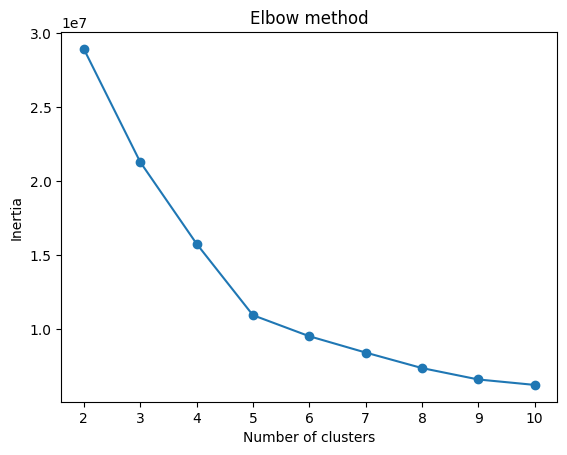

In [ ]:
import matplotlib.pyplot as plt

plt.plot(kmeans_results[kmeans_results['method']=='kmeans']['k'], kmeans_results[kmeans_results['method']=='kmeans']['inertia'], marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.show()

In [297]:
# On 5 clusters we see Elbow - the point where adding more clusters yields no significant increase in segmentation quality. 

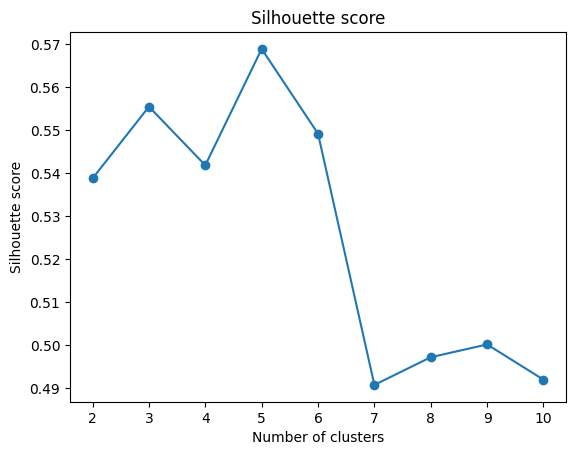

In [ ]:
plt.plot(kmeans_results[kmeans_results['method']=='kmeans']['k'], kmeans_results[kmeans_results['method']=='kmeans']['silhouette'], marker="o")#list(k_range)
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.title("Silhouette score")
plt.show()

In [ ]:
# segmentation with 5 clusters also provides the optimal silhouette score and the best clustering quality

In [ ]:
# Check of segmentation method - Agglomerative Clustering

from sklearn.cluster import AgglomerativeClustering

agg_results = []

for k in range(2, 9):
    agg = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )
    
    labels = agg.fit_predict(X_clean)

    cluster_share = pd.Series(labels).value_counts(normalize=True).sort_index()
    
    agg_results.append({
        "method": "agglomerative",
        "k": k,
        "silhouette": silhouette_score(X_clean, labels),
        "largest_cluster_share": cluster_share.max(),
        "smallest_cluster_share": cluster_share.min(),
        "cluster_share": cluster_share.to_dict()
  })

agg_results = pd.DataFrame(agg_results)

agg_results.sort_values("silhouette", ascending=False)

,method,k,silhouette,largest_cluster_share,smallest_cluster_share,cluster_share
3,agglomerative,5,0.494541,0.664500,0.036667,"{0: 0.13266666666666665, 1: 0.6645, 2: 0.112, ..."
2,agglomerative,4,0.469162,0.718667,0.036667,"{0: 0.7186666666666667, 1: 0.13266666666666665..."
4,agglomerative,6,0.462961,0.664500,0.034167,"{0: 0.6645, 1: 0.0985, 2: 0.112, 3: 0.03666666..."
1,agglomerative,3,0.450228,0.755333,0.112000,"{0: 0.7553333333333333, 1: 0.13266666666666665..."
0,agglomerative,2,0.424722,0.867333,0.132667,"{0: 0.8673333333333333, 1: 0.13266666666666665}"
6,agglomerative,8,0.419699,0.541667,0.026833,"{0: 0.5416666666666666, 1: 0.0985, 2: 0.085166..."
5,agglomerative,7,0.411691,0.541667,0.034167,"{0: 0.112, 1: 0.0985, 2: 0.5416666666666666, 3..."


In [ ]:
# Check of segmentation method - Birch

from sklearn.cluster import Birch

birch_results = []

for threshold in [0.2, 0.3, 0.5, 0.7, 1.0]:
    for k in range(2, 9):
        birch = Birch(
            n_clusters=k,
            threshold=threshold,
            branching_factor=50
        )
        
        labels = birch.fit_predict(X_clean)

        cluster_share = pd.Series(labels).value_counts(normalize=True).sort_index()
        
        birch_results.append({
            "method": "birch",
            "threshold": threshold,
            "k": k,
            "silhouette": silhouette_score(X_clean, labels),
            "largest_cluster_share": cluster_share.max(),
            "smallest_cluster_share": cluster_share.min(),
            "cluster_share": cluster_share.to_dict()
        })

birch_results = pd.DataFrame(birch_results)
birch_results.sort_values("silhouette", ascending=False).head(20)

,method,threshold,k,silhouette,largest_cluster_share,smallest_cluster_share,cluster_share
17,birch,0.5,5,0.494541,0.664500,0.036667,"{0: 0.13266666666666665, 1: 0.6645, 2: 0.112, ..."
10,birch,0.3,5,0.494541,0.664500,0.036667,"{0: 0.13266666666666665, 1: 0.6645, 2: 0.112, ..."
3,birch,0.2,5,0.494541,0.664500,0.036667,"{0: 0.13266666666666665, 1: 0.6645, 2: 0.112, ..."
31,birch,1.0,5,0.494541,0.664500,0.036667,"{0: 0.13266666666666665, 1: 0.6645, 2: 0.112, ..."
24,birch,0.7,5,0.494541,0.664500,0.036667,"{0: 0.13266666666666665, 1: 0.6645, 2: 0.112, ..."
2,birch,0.2,4,0.469162,0.718667,0.036667,"{0: 0.7186666666666667, 1: 0.13266666666666665..."
30,birch,1.0,4,0.469162,0.718667,0.036667,"{0: 0.7186666666666667, 1: 0.13266666666666665..."
23,birch,0.7,4,0.469162,0.718667,0.036667,"{0: 0.7186666666666667, 1: 0.13266666666666665..."
9,birch,0.3,4,0.469162,0.718667,0.036667,"{0: 0.7186666666666667, 1: 0.13266666666666665..."
16,birch,0.5,4,0.469162,0.718667,0.036667,"{0: 0.7186666666666667, 1: 0.13266666666666665..."


In [ ]:
# Choosing the best segmentation method according to silhouette score, cluster size and next in case of kmeans Elbow graph

comparison_results = pd.concat([kmeans_results, agg_results, birch_results],ignore_index=True)

comparison_results.sort_values("silhouette",ascending=False).head(20)

,method,k,inertia,silhouette,largest_cluster_share,smallest_cluster_share,cluster_share,threshold
3,kmeans,5,1.093228e+07,0.568829,0.677167,0.073167,"{0: 0.6771666666666667, 1: 0.07316666666666667...",NaN
1,kmeans,3,2.130260e+07,0.555417,0.832667,0.078833,"{0: 0.8326666666666667, 1: 0.0885, 2: 0.078833...",NaN
4,kmeans,6,9.507837e+06,0.549152,0.652667,0.038333,"{0: 0.6526666666666666, 1: 0.03833333333333333...",NaN
2,kmeans,4,1.576931e+07,0.541818,0.751500,0.076000,"{0: 0.076, 1: 0.7515, 2: 0.0875, 3: 0.085}",NaN
0,kmeans,2,2.895455e+07,0.538768,0.906500,0.093500,"{0: 0.0935, 1: 0.9065}",NaN
7,kmeans,9,6.579251e+06,0.500216,0.552500,0.035000,"{0: 0.0715, 1: 0.03816666666666667, 2: 0.0365,...",NaN
6,kmeans,8,7.351661e+06,0.497252,0.577500,0.036667,"{0: 0.5775, 1: 0.08233333333333333, 2: 0.0375,...",NaN
12,agglomerative,5,NaN,0.494541,0.664500,0.036667,"{0: 0.13266666666666665, 1: 0.6645, 2: 0.112, ...",NaN
33,birch,5,NaN,0.494541,0.664500,0.036667,"{0: 0.13266666666666665, 1: 0.6645, 2: 0.112, ...",0.5
26,birch,5,NaN,0.494541,0.664500,0.036667,"{0: 0.13266666666666665, 1: 0.6645, 2: 0.112, ...",0.3


In [ ]:
# 8. Final model, K-Means k=5

kmeans = KMeans(n_clusters=5, random_state=352, n_init=10)
labels = kmeans.fit_predict(X_clean)

print(pd.Series(labels).value_counts(normalize=True).sort_index())

0    0.677167
1    0.073167
2    0.084333
3    0.086667
4    0.078667
Name: proportion, dtype: float64


In [ ]:
main["cluster"] = kmeans.fit_predict(X_clean)

In [ ]:
# Clusters profile

profile = main.groupby("cluster").mean(numeric_only=True)

global_mean = main.drop(columns=["cluster"], errors="ignore").mean(numeric_only=True)

cluster_index = profile / global_mean

cluster_index.T

cluster,0,1,2,3,4
user_id,1.005657,0.986667,0.964614,1.001748,0.999713
session_count,0.952083,1.100547,1.110857,1.082866,1.108823
session_length_mean,0.953158,1.100547,1.102905,1.081301,1.109816
session_length_sum,0.909002,1.189569,1.205167,1.155180,1.216091
session_length_median,0.953140,1.111926,1.093639,1.084973,1.105276
...,...,...,...,...,...
salary,0.977379,1.057201,1.031731,1.037851,1.065701
age,0.999476,0.997810,0.992786,1.005428,1.008276
previous_purchases_flg,0.994173,1.292519,1.287916,0.723855,0.773662
in_users_base_flg,1.000193,0.926265,1.002656,1.024081,1.037540


In [ ]:
# top 20 most significant features defining every cluster 

for c in sorted(main["cluster"].unique()):
    print(f"\nCluster {c}")
    display(
        cluster_index.loc[c]
        .sort_values(ascending=False)
        .head(20)
    )


Cluster 0


session_length_min_count_by_populacja_50k_350000.0     1.391365
session_length_min_count_by_populacja_50k_700000.0     1.387477
session_length_min_sum_by_populacja_50k_700000.0       1.382569
session_length_min_sum_by_populacja_50k_350000.0       1.377613
session_length_min_count_by_populacja_50k_1900000.0    1.376085
session_length_min_sum_by_populacja_50k_1900000.0      1.374222
session_length_min_sum_by_populacja_50k_650000.0       1.372079
session_length_min_mean_by_populacja_50k_350000.0      1.361086
session_length_min_count_by_populacja_50k_650000.0     1.356643
session_length_min_sum_by_populacja_50k_550000.0       1.347300
session_length_min_count_by_populacja_50k_250000.0     1.340774
session_length_min_count_by_populacja_50k_550000.0     1.335626
session_length_min_mean_by_populacja_50k_700000.0      1.331726
session_length_min_sum_by_populacja_50k_250000.0       1.317851
session_length_min_count_by_populacja_50k_850000.0     1.298514
session_length_min_mean_by_populacja_50k


Cluster 1


session_length_min_sum_by_populacja_50k_200000.0                           9.901099
session_length_min_count_by_populacja_50k_200000.0                         8.795678
session_length_min_mean_by_populacja_50k_200000.0                          7.134003
session_length_min_mean_by_rodzaj obiektu_popul_schronisko turystyczne     3.063951
session_length_min_count_by_rodzaj obiektu_popul_schronisko turystyczne    2.294531
session_length_min_sum_by_rodzaj obiektu_popul_schronisko turystyczne      1.889039
session_length_min_sum_by_rodzaj obiektu_popul_część miasta                1.774096
session_length_min_count_by_rodzaj obiektu_popul_część miasta              1.604967
session_length_min_count_by_rodzaj obiektu_popul_leśniczówka               1.524022
session_length_min_sum_by_rodzaj obiektu_popul_leśniczówka                 1.436112
session_length_min_mean_by_rodzaj obiektu_popul_część miasta               1.325241
session_length_min_mean_by_rodzaj obiektu_popul_leśniczówka                1


Cluster 2


session_length_min_sum_by_populacja_50k_150000.0                 9.004911
session_length_min_count_by_populacja_50k_150000.0               8.104435
session_length_min_mean_by_populacja_50k_150000.0                6.326722
session_length_min_mean_by_populacja_50k_300000.0                2.356012
session_length_min_sum_by_rodzaj obiektu_popul_część miasta      2.021179
session_length_min_sum_by_rodzaj obiektu_popul_miasto            1.867325
session_length_min_count_by_rodzaj obiektu_popul_część miasta    1.856990
session_length_min_mean_by_rodzaj obiektu_popul_miasto           1.848054
session_length_min_sum_by_populacja_50k_300000.0                 1.836453
session_length_min_count_by_populacja_50k_300000.0               1.775703
session_length_min_sum_by_rodzaj obiektu_popul_inne              1.505909
session_length_min_count_by_rodzaj obiektu_popul_miasto          1.456609
session_length_min_sum_by_day_type_holiday                       1.363891
session_length_min_sum_by_is_holiday_T


Cluster 3


session_length_min_sum_by_populacja_50k_100000.0                 8.098982
session_length_min_count_by_populacja_50k_100000.0               7.188020
session_length_min_mean_by_populacja_50k_100000.0                5.443509
session_length_min_mean_by_populacja_50k_850000.0                2.031917
session_length_min_mean_by_populacja_50k_300000.0                1.847194
session_length_min_sum_by_populacja_50k_300000.0                 1.772303
session_length_min_mean_by_rodzaj obiektu_popul_miasto           1.672682
session_length_min_count_by_populacja_50k_300000.0               1.656049
session_length_min_mean_by_populacja_50k_250000.0                1.599993
session_length_min_sum_by_rodzaj obiektu_popul_miasto            1.591003
session_length_min_sum_by_populacja_50k_850000.0                 1.559338
session_length_min_count_by_rodzaj obiektu_popul_miasto          1.520744
session_length_min_sum_by_rodzaj obiektu_popul_część miasta      1.437914
session_length_min_mean_by_populacja_5


Cluster 4


session_length_min_sum_by_rodzaj obiektu_popul_osada            8.739487
session_length_min_count_by_rodzaj obiektu_popul_osada          6.932003
session_length_min_mean_by_rodzaj obiektu_popul_osada           6.168290
session_length_min_mean_by_populacja_50k_400000.0               5.406567
session_length_min_sum_by_populacja_50k_400000.0                4.278657
session_length_min_count_by_populacja_50k_400000.0              3.931016
session_length_min_count_by_rodzaj obiektu_popul_inne           2.529484
session_length_min_sum_by_rodzaj obiektu_popul_inne             2.367265
session_length_min_sum_by_rodzaj obiektu_popul_leśniczówka      2.225253
session_length_min_mean_by_rodzaj obiektu_popul_inne            2.145763
session_length_min_count_by_rodzaj obiektu_popul_leśniczówka    2.007136
session_length_min_sum_by_rodzaj obiektu_popul_kolonia wsi      1.949176
session_length_min_sum_by_rodzaj obiektu_popul_osada leśna      1.905902
session_length_min_mean_by_rodzaj obiektu_popul_leś

In [ ]:
# Distinct user segments

# Cluster 0 - 68% of user base
# Citizens of big cities > 300k 

# Cluster 1 - 7,3% of user base
# Citizens of middle size cities ~ 150k
# they like spending time actively in mountains and forests
# they like to buy premium services
# they use app mostly in workdays, evenings and  nights

# Cluster 2 - 8,4% of user base
# Citizens of middle size cities ~ 150k
# they use app mostly in official holidays period
# they like to buy premium services

# Cluster 3 - 8,7% of user base
# Citizens of mostly small but also medium and big cities 

# Cluster 4 - 7,9% of user base
# Citizens of country side with some visits to medium cities

In [142]:
main[main['in_users_base_flg']==1]['previous_purchases_flg'].value_counts()

previous_purchases_flg
0    3906
1     860
Name: count, dtype: int64

In [143]:
860/3906

0.2201740911418331

# The company currently have 3906 users of which 22% are using premium services?

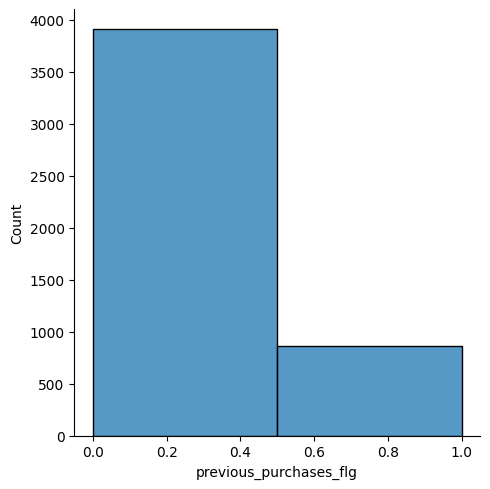

In [144]:
sns.displot(main[main['in_users_base_flg']==1]['previous_purchases_flg'], bins=2, kde=False)

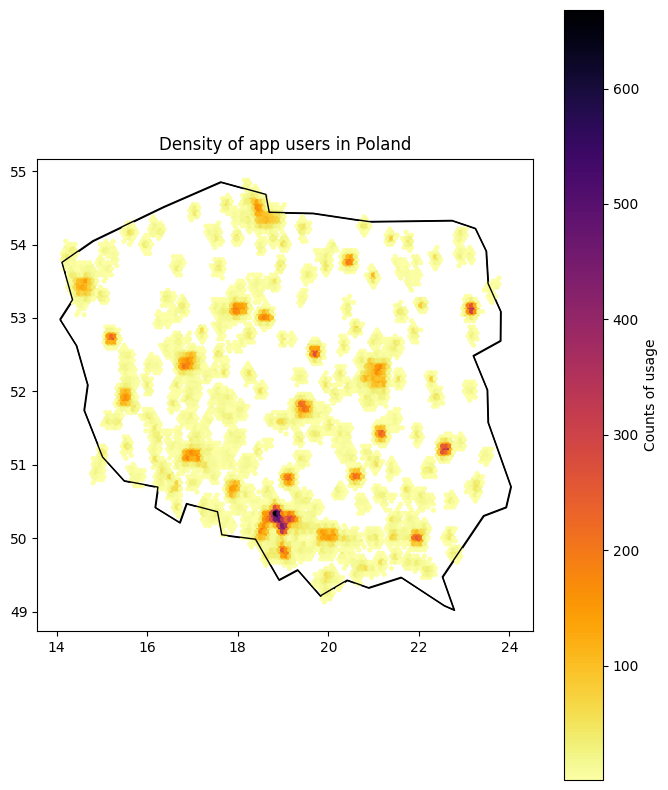

In [225]:
import geopandas as gpd
import matplotlib.pyplot as plt

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
poland = world[world["NAME"] == "Poland"]

fig, ax = plt.subplots(figsize=(8, 10))

poland.plot(ax=ax, color="white", edgecolor="black")

hb = ax.hexbin(
    session_geo["lon"],
    session_geo["lat"],
    gridsize=120,
    mincnt=1,
    cmap="inferno_r"
)

poland.boundary.plot(ax=ax, color="black", linewidth=1)

plt.colorbar(hb, ax=ax, label="Counts of usage")
ax.set_title("Density of app users in Poland")
plt.show()

# The app is still not popular in countryside distant from towns or with sparse population

In [146]:
main.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Columns: 152 entries, user_id to cluster
dtypes: float64(98), int32(1), int64(52), str(1)
memory usage: 6.9 MB


In [149]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score, precision_score, recall_score,average_precision_score
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import fbeta_score
from xgboost import XGBClassifier

In [ ]:
# Features and taget sets definitions

X, y = main.drop(["previous_purchases_flg","user_id"], axis=1), main["previous_purchases_flg"]

In [ ]:
# Dividing all data in 3 sets: validation 10%, train 72% and test 18%

X_tmp, X_valid, y_tmp, y_valid = train_test_split(
    X, y, test_size=0.1, random_state=325, stratify=np.ravel(y)
)

In [152]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.2, random_state=325, stratify=np.ravel(y_tmp)
)

In [ ]:
# Preparing piplines for features imputation and scaling/encoding based on col types for classification purposes

from sklearn.preprocessing import TargetEncoder

def build_preprocess(cat_cols, num_cols):

    # target encoder - fill every category of given feature with mean value of target for this category

    cat_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
        ("target_enc", TargetEncoder(target_type="binary", random_state=352))
    ])

    num_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median",add_indicator=True)),
        ("scaler", RobustScaler())
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols)
        ],
        remainder="drop"
    )

    return pre

In [ ]:
# Implementig pipline transformation on all data sets after fiting on train set

feature_cols = X_train.columns
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

pre = build_preprocess(cat_cols, num_cols)

X_train_sc = pre.fit_transform(pd.DataFrame(X_train, columns=feature_cols), y_train)
X_test_sc  = pre.transform(pd.DataFrame(X_test, columns=feature_cols))
X_valid_sc = pre.transform(pd.DataFrame(X_valid, columns=feature_cols))

C:\Users\Priv\AppData\Local\Temp\ipykernel_10716\3956236071.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()


In [155]:
y_train = pd.DataFrame(y_train)
y_train.columns = ["Class"]
y_train["Class"].value_counts()

Class
0    3551
1     769
Name: count, dtype: int64

In [236]:
769/3551

0.21655871585468883

In [ ]:
lr = LogisticRegression(
    l1_ratio=0,
    C=1.0,
    solver='lbfgs',
    max_iter=5000,
    class_weight='balanced'
)

lr.fit(X_train_sc, np.ravel(y_train))

y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]

class_report = classification_report(y_test, y_pred_lr)
print(class_report)

y_prob_val_lr = lr.predict_proba(X_valid_sc)[:, 1]

              precision    recall  f1-score   support

           0       0.92      0.75      0.83       888
           1       0.38      0.70      0.49       192

    accuracy                           0.74      1080
   macro avg       0.65      0.72      0.66      1080
weighted avg       0.82      0.74      0.77      1080



In [158]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=50,
    min_samples_leaf=20,
    bootstrap=True,
    class_weight="balanced_subsample",
    max_features="sqrt",
    random_state=325,
    n_jobs=-1
)

rf.fit(X_train_sc, np.ravel(y_train))
y_pred_rf = rf.predict(X_test_sc)
y_prob_rf = rf.predict_proba(X_test_sc)[:, 1]

class_report = classification_report(y_test, y_pred_rf)
print(class_report)
y_prob_val_rf = rf.predict_proba(X_valid_sc)[:, 1]

              precision    recall  f1-score   support

           0       0.89      0.88      0.89       888
           1       0.48      0.52      0.50       192

    accuracy                           0.81      1080
   macro avg       0.69      0.70      0.69      1080
weighted avg       0.82      0.81      0.82      1080



In [ ]:
# Hyperparameter tuning of Random Forest with average_pricision (AUC_PR) as function to optimize

import optuna

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=325
)

def objective_rf(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1000),
        "max_depth": trial.suggest_int("max_depth", 4, 25),
        "min_samples_split": trial.suggest_int("min_samples_split", 10, 100),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 2, 50),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5]),
        "class_weight": trial.suggest_categorical(
            "class_weight",
            [None, "balanced", "balanced_subsample"]
        ),
        "bootstrap": True,
        "random_state": 325,
        "n_jobs": -1
    }

    model = RandomForestClassifier(**params)
    
    scores = cross_val_score(
        model,
        X_train_sc,
        np.ravel(y_train),
        cv=cv,
        scoring="average_precision",
        n_jobs=-1
    )

    return scores.mean()

In [161]:
rf_op = optuna.create_study(direction="maximize")
rf_op.optimize(objective_rf, n_trials=50)

print(rf_op.best_params)

[I 2026-07-06 19:40:46,539] A new study created in memory with name: no-name-ea607def-6c2d-41e6-9e00-0ba4ae35ee6f
[I 2026-07-06 19:40:57,193] Trial 0 finished with value: 0.4730397456304997 and parameters: {'n_estimators': 579, 'max_depth': 24, 'min_samples_split': 62, 'min_samples_leaf': 39, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 0 with value: 0.4730397456304997.
[I 2026-07-06 19:41:06,092] Trial 1 finished with value: 0.45792306845246616 and parameters: {'n_estimators': 512, 'max_depth': 6, 'min_samples_split': 20, 'min_samples_leaf': 27, 'max_features': 'log2', 'class_weight': None}. Best is trial 0 with value: 0.4730397456304997.
[I 2026-07-06 19:41:27,342] Trial 2 finished with value: 0.47654354827817336 and parameters: {'n_estimators': 453, 'max_depth': 17, 'min_samples_split': 89, 'min_samples_leaf': 49, 'max_features': 0.3, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.47654354827817336.
[I 2026-07-06 19:41:41,298] Trial 3 finished with value:

{'n_estimators': 884, 'max_depth': 13, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.3, 'class_weight': None}


In [162]:
rf_hyp = RandomForestClassifier(**rf_op.best_params)

rf_hyp.fit(X_train_sc, np.ravel(y_train))
y_pred_rf_hyp = rf_hyp.predict(X_test_sc)
y_prob_rf_hyp = rf_hyp.predict_proba(X_test_sc)[:, 1]

class_report = classification_report(y_test, y_pred_rf_hyp)
print(class_report)
y_prob_val_rf_hyp = rf_hyp.predict_proba(X_valid_sc)[:, 1]

              precision    recall  f1-score   support

           0       0.85      1.00      0.92       888
           1       0.93      0.20      0.33       192

    accuracy                           0.86      1080
   macro avg       0.89      0.60      0.63      1080
weighted avg       0.87      0.86      0.81      1080



In [184]:
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric=["aucpr"],

    n_estimators=2000,
    learning_rate=0.03,

    max_depth=4,
    min_child_weight=20,
    gamma=0.1,

    subsample=0.75,
    colsample_bytree=0.7,
    colsample_bylevel=0.8,

    reg_lambda=5.0,
    reg_alpha=0.5,

    scale_pos_weight=5,

    tree_method="hist",
    random_state=325,
    verbosity=0,
    n_jobs=-1,
    early_stopping_rounds=50
)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_sc,
    np.ravel(y_train),
    test_size=0.2,
    random_state=325,
    stratify=np.ravel(y_train)
)

xgb.fit(
    X_tr,
    y_tr,
    eval_set=[(X_val, y_val)],
    verbose=50
)

y_pred_xgb = xgb.predict(X_test_sc)
y_prob_xgb = xgb.predict_proba(X_test_sc)[:, 1]

class_report = classification_report(y_test, y_pred_xgb)
print(class_report)

y_prob_val_xgb = xgb.predict_proba(X_valid_sc)[:, 1]

[0]	validation_0-aucpr:0.33627
[50]	validation_0-aucpr:0.56974
[100]	validation_0-aucpr:0.59558
[150]	validation_0-aucpr:0.61125
[200]	validation_0-aucpr:0.61133
[250]	validation_0-aucpr:0.61510
[296]	validation_0-aucpr:0.61128
              precision    recall  f1-score   support

           0       0.91      0.82      0.86       888
           1       0.43      0.63      0.51       192

    accuracy                           0.79      1080
   macro avg       0.67      0.73      0.69      1080
weighted avg       0.83      0.79      0.80      1080



In [185]:
from lightgbm import early_stopping, log_evaluation

eval_set = [(X_val, y_val)]

lgb = LGBMClassifier(
    scale_pos_weight = 5,
    max_depth = 5,
    num_leaves = 20,
    min_child_samples = 80,
    feature_fraction = 0.8,
    bagging_fraction = 0.8,
    bagging_freq = 1,
    reg_lambda = 3.0,
    reg_alpha = 0.0,
    learning_rate = 0.03,
    n_estimators = 2000,
    objective = 'binary',
    metric = 'aucpr',
    random_state = 325,
    verbose = -1,
    n_jobs = -1
)

lgb.fit(
    X_tr,
    y_tr,
    eval_set=eval_set,
    eval_metric='average_precision', 
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(period=50)
    ]
)

y_pred_lgb = lgb.predict(X_test_sc)
y_prob_lgb = lgb.predict_proba(X_test_sc)[:, 1]

class_report = classification_report(y_test, y_pred_lgb)
print(class_report)

y_prob_val_lgb = lgb.predict_proba(X_valid_sc)[:, 1]

Training until validation scores don't improve for 50 rounds
[50]	valid_0's average_precision: 0.584121
[100]	valid_0's average_precision: 0.611459
[150]	valid_0's average_precision: 0.614794
[200]	valid_0's average_precision: 0.614287
Early stopping, best iteration is:
[157]	valid_0's average_precision: 0.617041
              precision    recall  f1-score   support

           0       0.91      0.81      0.86       888
           1       0.41      0.63      0.50       192

    accuracy                           0.78      1080
   macro avg       0.66      0.72      0.68      1080
weighted avg       0.82      0.78      0.79      1080



c:\Users\Priv\langchain-ai-07112025\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Priv\langchain-ai-07112025\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Priv\langchain-ai-07112025\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Hyperparameter tuning of XGBoost with average_pricision (AUC_PR) as function to optimize
 
def objective_xgb(trial):

    params = {
        "objective": "binary:logistic",
        "eval_metric": "aucpr",
        "tree_method": "hist",

        "n_estimators": trial.suggest_int("n_estimators", 800, 3000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),

        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "min_child_weight": trial.suggest_float("min_child_weight", 5, 100, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 0.7),

        "subsample": trial.suggest_float("subsample", 0.5, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 0.9),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),

        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 30.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.001, 5.0, log=True),

        "scale_pos_weight": trial.suggest_float(
            "scale_pos_weight",
            5 * 0.5,
            5 * 1.5
        ),

        "early_stopping_rounds": 50,
        "random_state": 325,
        "n_jobs": -1,
        "verbosity": 0,
    }

    model = XGBClassifier(**params)

    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    y_val_prob = model.predict_proba(X_val)[:, 1]

    return average_precision_score(y_val, y_val_prob)

In [187]:
xgb_op = optuna.create_study(direction="maximize")
xgb_op.optimize(objective_xgb, n_trials=50)

print(xgb_op.best_params)

[I 2026-07-06 20:54:16,081] A new study created in memory with name: no-name-b0652e82-eca4-4cbb-a9d1-e840325f4aad
[I 2026-07-06 20:54:16,884] Trial 0 finished with value: 0.5934174331868665 and parameters: {'n_estimators': 1160, 'learning_rate': 0.036188685644523766, 'max_depth': 5, 'min_child_weight': 6.679503175081016, 'gamma': 0.3512807962234984, 'subsample': 0.5082925007200173, 'colsample_bytree': 0.7975269334824002, 'colsample_bylevel': 0.5960807534581882, 'reg_lambda': 3.0656874666417977, 'reg_alpha': 1.5102679798702296, 'scale_pos_weight': 5.122796021943084}. Best is trial 0 with value: 0.5934174331868665.
[I 2026-07-06 20:54:17,539] Trial 1 finished with value: 0.583461522658923 and parameters: {'n_estimators': 2622, 'learning_rate': 0.056633443168729806, 'max_depth': 6, 'min_child_weight': 54.70797342199774, 'gamma': 0.2596071226213663, 'subsample': 0.5098988608311512, 'colsample_bytree': 0.79151640207837, 'colsample_bylevel': 0.901862105623832, 'reg_lambda': 2.110632546208111

{'n_estimators': 809, 'learning_rate': 0.06260544582767842, 'max_depth': 6, 'min_child_weight': 12.055943152249563, 'gamma': 0.575454078912842, 'subsample': 0.8922729578795647, 'colsample_bytree': 0.5681528271474137, 'colsample_bylevel': 0.603994445423655, 'reg_lambda': 15.944182580213777, 'reg_alpha': 0.28386189151235547, 'scale_pos_weight': 6.310657769120592}


In [188]:
xgb_hyp = XGBClassifier(**xgb_op.best_params)

xgb_hyp.fit(X_train_sc, np.ravel(y_train))

y_pred_xgb_hyp = xgb_hyp.predict(X_test_sc)
y_prob_xgb_hyp = xgb_hyp.predict_proba(X_test_sc)[:, 1]

class_report = classification_report(y_test, y_pred_xgb_hyp)
print(class_report)

y_prob_val_xgb_hyp = xgb_hyp.predict_proba(X_valid_sc)[:, 1]

              precision    recall  f1-score   support

           0       0.88      0.91      0.89       888
           1       0.50      0.41      0.45       192

    accuracy                           0.82      1080
   macro avg       0.69      0.66      0.67      1080
weighted avg       0.81      0.82      0.81      1080



In [ ]:
# Hyperparameter tuning of LigthGBM with average_pricision (AUC_PR) as function to optimize

def objective_lgb(trial):

    max_depth = trial.suggest_int("max_depth", 3, 8)
    max_leaves = min(2 ** max_depth, 128)

    params = {
        "objective": "binary",
        "metric": "aucpr",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": 325,
        "n_jobs": -1,

        "n_estimators": 5000,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.08, log=True),

        "max_depth": max_depth,
        "num_leaves": trial.suggest_int("num_leaves", 8, max_leaves),

        "min_child_samples": trial.suggest_int("min_child_samples", 20, 150),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-3, 20.0, log=True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),

        "subsample": trial.suggest_float("subsample", 0.5, 0.95),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 0.95),

        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 20.0, log=True),

        "scale_pos_weight": trial.suggest_float(
            "scale_pos_weight",
            5 * 0.5,
            5 * 1.5
        ),
    }   

    model = LGBMClassifier(**params)

    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="average_precision",
        callbacks=[
            early_stopping(stopping_rounds=50, verbose=False)
        ]
    )

    y_val_prob = model.predict_proba(X_val)[:, 1]

    return average_precision_score(y_val, y_val_prob)

In [190]:
lgb_op = optuna.create_study(direction="maximize")
lgb_op.optimize(objective_lgb, n_trials=50)

print(lgb_op.best_params)

[I 2026-07-06 20:56:27,157] A new study created in memory with name: no-name-f1dea4d5-e156-4e90-8176-7813f52c5a25
c:\Users\Priv\langchain-ai-07112025\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-07-06 20:56:28,172] Trial 0 finished with value: 0.6204049541598557 and parameters: {'max_depth': 8, 'learning_rate': 0.02606569455053241, 'num_leaves': 107, 'min_child_samples': 135, 'min_child_weight': 1.1379355185771785, 'min_split_gain': 0.5260029539715737, 'subsample': 0.7342020267588418, 'colsample_bytree': 0.8851903245407952, 'reg_alpha': 2.634180381051087, 'reg_lambda': 0.0023508040661530255, 'scale_pos_weight': 3.9694609545794353}. Best is trial 0 with value: 0.6204049541598557.
c:\Users\Priv\langchain-ai-07112025\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted w

{'max_depth': 4, 'learning_rate': 0.022118654841371505, 'num_leaves': 9, 'min_child_samples': 137, 'min_child_weight': 0.01266394117903319, 'min_split_gain': 0.8908659291200437, 'subsample': 0.8718626023513493, 'colsample_bytree': 0.6806643038972006, 'reg_alpha': 0.01099467472533577, 'reg_lambda': 0.028291486763684308, 'scale_pos_weight': 2.695115689099863}


In [191]:
lgb_hyp = LGBMClassifier(**lgb_op.best_params)

lgb_hyp.fit(
    X_train_sc,
    np.ravel(y_train),
    eval_set=eval_set,
    eval_metric='average_precision',  
    callbacks=[
        early_stopping(stopping_rounds=50)
    ]
)

y_pred_lgb_hyp = lgb_hyp.predict(X_test_sc)
y_prob_lgb_hyp = lgb_hyp.predict_proba(X_test_sc)[:, 1]

class_report = classification_report(y_test, y_pred_lgb_hyp)
print(class_report)

y_prob_val_lgb_hyp = lgb_hyp.predict_proba(X_valid_sc)[:, 1]

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's average_precision: 0.662933	valid_0's binary_logloss: 0.399913
              precision    recall  f1-score   support

           0       0.87      0.93      0.90       888
           1       0.54      0.38      0.45       192

    accuracy                           0.83      1080
   macro avg       0.71      0.66      0.67      1080
weighted avg       0.82      0.83      0.82      1080



c:\Users\Priv\langchain-ai-07112025\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Priv\langchain-ai-07112025\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Priv\langchain-ai-07112025\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Functions for model ranking on technical and business scores

def top_k_capture(y_true, y_prob, top_pct=0.10):
    y_true = pd.Series(np.ravel(y_true)).reset_index(drop=True)
    y_prob = pd.Series(np.ravel(y_prob)).reset_index(drop=True)

    n_top = int(np.ceil(len(y_prob) * top_pct))

    top_idx = y_prob.sort_values(ascending=False).head(n_top).index

    positives_in_top = (y_true.loc[top_idx] == 1).sum()
    total_positives = (y_true == 1).sum()

    return positives_in_top / total_positives

def make_results_row(y_true, y_prob, y_pred, y_prob_val):

    y_true = pd.Series(y_true).reset_index(drop=True)
    y_prob = pd.Series(y_prob).reset_index(drop=True).clip(1e-6, 1-1e-6)

    res = {}

    # ranking
    res["Precision"] = round(precision_score(y_test, y_pred, zero_division=0),2)
    res["Recall"] = round(recall_score(y_test, y_pred, zero_division=0),2)
    res["F1"] = round(f1_score(y_test, y_pred, zero_division=0),2)
    res["F2"] = round(fbeta_score(y_test, y_pred, beta=2, zero_division=0),2)

    # test and validation scores
    res["PR_AUC_TEST"] = round(average_precision_score(y_test, y_prob),3)
    res["PR_AUC_VALID"] = round(average_precision_score(y_true, y_prob_val),3) # the better for ranking purposes and picking top n for communication
    res["ROC_AUC_VALID"] = round(roc_auc_score(y_true, y_prob_val),3) # the better for general classification

    # business scores - how many percent of premium products was bought in top x% on validation set

    res["TOP 1% PCT"] = round(top_k_capture(y_valid, y_prob_val, 0.01), 3)
    res["TOP 5% PCT"] = round(top_k_capture(y_valid, y_prob_val, 0.05), 3)
    res["TOP 10% PCT"] = round(top_k_capture(y_valid, y_prob_val, 0.10), 3)

    return res

In [192]:
row_lr = make_results_row(y_valid, y_prob_lr, y_pred_lr, y_prob_val_lr)
row_rf = make_results_row(y_valid, y_prob_rf, y_pred_rf, y_prob_val_rf)
row_xgb = make_results_row(y_valid, y_prob_xgb, y_pred_xgb, y_prob_val_xgb)
row_lgb = make_results_row(y_valid, y_prob_lgb, y_pred_lgb, y_prob_val_lgb)
row_rf_hyp = make_results_row(y_valid, y_prob_rf_hyp, y_pred_rf_hyp, y_prob_val_rf_hyp)
row_xgb_hyp = make_results_row(y_valid, y_prob_xgb_hyp, y_pred_xgb_hyp, y_prob_val_xgb_hyp)
row_lgb_hyp = make_results_row(y_valid, y_prob_lgb_hyp, y_pred_lgb_hyp, y_prob_val_lgb_hyp)

rows = {
    "LR": row_lr,
    "RF": row_rf,
    "RF_HYP": row_rf_hyp,
    "XGB": row_xgb,
    "LGB": row_lgb,
    "XGB_HYP": row_xgb_hyp,
    "LGB_HYP": row_lgb_hyp
}

results = pd.DataFrame(rows)
results = results.apply(pd.to_numeric, errors='coerce')

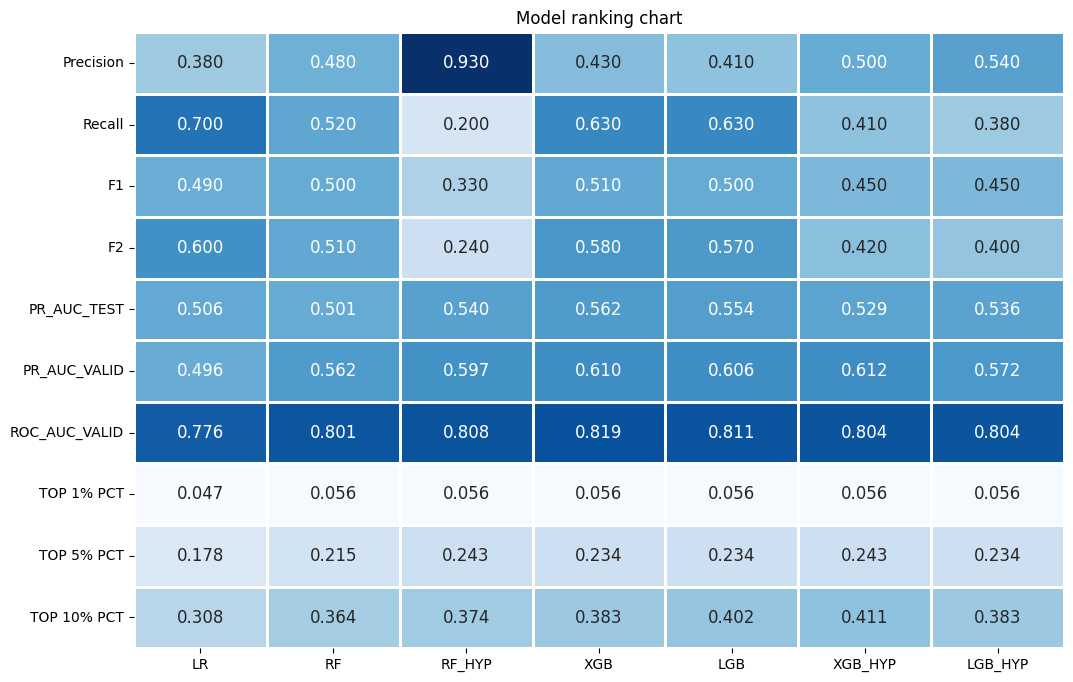

In [230]:
plt.figure(figsize=(12, 8))
plt.title("Model ranking chart")
sns.heatmap(results, cmap="Blues", linewidths=1, cbar=False, annot_kws={"fontsize": 12}, annot=True, fmt=".3f")
plt.show()

In [243]:
def calc_lift_capture(y_true, y_prob, model_name, top_pcts=None):
    
    # Calculates capture and lift for top X% ranked by model score.
    # capture = % of all positives captured in top X%
    # lift = capture / X%
        
    if top_pcts is None:
        top_pcts = np.arange(0.01, 0.11, 0.01)

    y_true = pd.Series(np.ravel(y_true)).reset_index(drop=True)
    y_prob = pd.Series(np.ravel(y_prob)).reset_index(drop=True)

    df = pd.DataFrame({
        "y_true": y_true,
        "y_prob": y_prob
    })

    df = df.sort_values("y_prob", ascending=False).reset_index(drop=True)

    total_positives = df["y_true"].sum()
    n = len(df)

    rows = []

    for pct in top_pcts:
        n_top = int(np.ceil(n * pct))

        top_df = df.iloc[:n_top]

        positives_in_top = top_df["y_true"].sum()

        capture = positives_in_top / total_positives if total_positives > 0 else np.nan
        lift = capture / pct if pct > 0 else np.nan

        precision_at_k = positives_in_top / n_top if n_top > 0 else np.nan

        rows.append({
            "model": model_name,
            "top_pct": pct,
            "top_pct_label": f"{int(pct * 100)}%",
            "n_top": n_top,
            "positives_in_top": positives_in_top,
            "capture": capture,
            "lift": lift,
            "precision_at_k": precision_at_k
        })

    return pd.DataFrame(rows)

In [244]:
models_probs = {
#    "LR": y_prob_val_lr,
#    "RF": y_prob_val_rf,
#    "RF_HYP": y_prob_val_rf_hyp,
    "XGB": y_prob_val_xgb,
    "LGB": y_prob_val_lgb,
    "XGB_HYP": y_prob_val_xgb_hyp,
#    "LGB_HYP": y_prob_val_lgb_hyp
}

lift_capture_results = pd.concat([calc_lift_capture(y_valid, prob, model_name) for model_name, 
                                  prob in models_probs.items()]
                                 ,ignore_index=True)

In [245]:
lift_capture_results.head(20)

,model,top_pct,top_pct_label,n_top,positives_in_top,capture,lift,precision_at_k
0,XGB,0.01,1%,6,6,0.056075,5.607477,1.000000
1,XGB,0.02,2%,12,12,0.112150,5.607477,1.000000
2,XGB,0.03,3%,18,17,0.158879,5.295950,0.944444
3,XGB,0.04,4%,24,21,0.196262,4.906542,0.875000
4,XGB,0.05,5%,30,25,0.233645,4.672897,0.833333
5,XGB,0.06,6%,36,29,0.271028,4.517134,0.805556
6,XGB,0.07,6%,42,32,0.299065,4.272363,0.761905
7,XGB,0.08,8%,48,34,0.317757,3.971963,0.708333
8,XGB,0.09,9%,54,36,0.336449,3.738318,0.666667
9,XGB,0.10,10%,60,41,0.383178,3.831776,0.683333


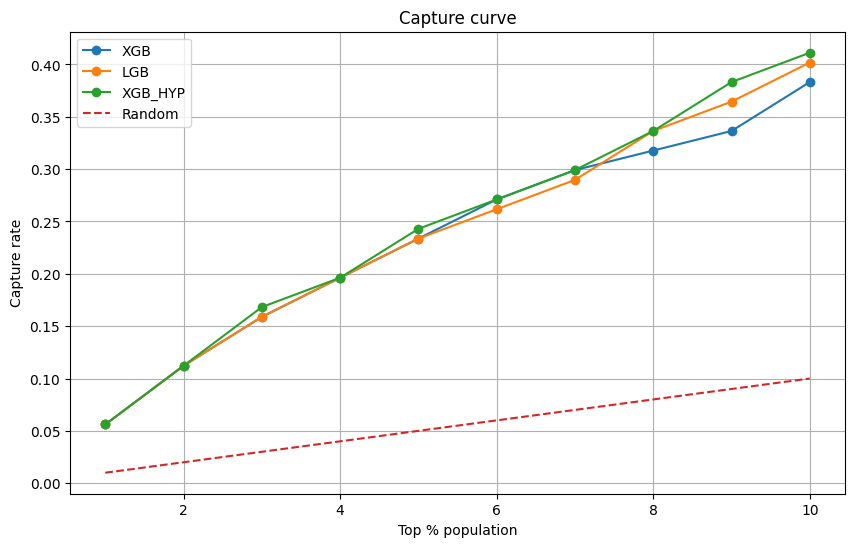

In [246]:
plt.figure(figsize=(10, 6))

for model_name in lift_capture_results["model"].unique():
    tmp = lift_capture_results[lift_capture_results["model"] == model_name]

    plt.plot(tmp["top_pct"] * 100, tmp["capture"], marker="o", label=model_name)

# the line of random choice

plt.plot(lift_capture_results["top_pct"].unique() * 100, lift_capture_results["top_pct"].unique(), linestyle="--", label="Random")

plt.xlabel("Top % population")
plt.ylabel("Capture rate")
plt.title("Capture curve")
plt.legend()
plt.grid(True)
plt.show()

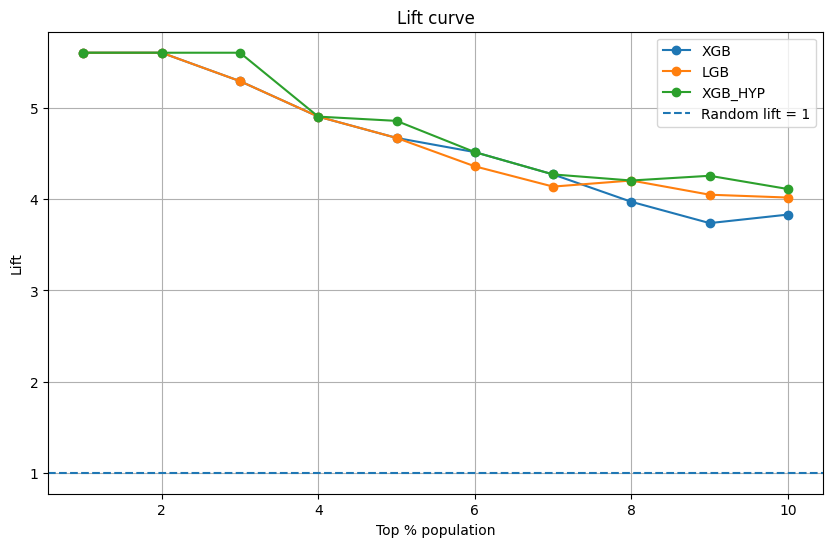

In [247]:
plt.figure(figsize=(10, 6))

# Data for models lift in top 10% of population

for model_name in lift_capture_results["model"].unique():
    tmp = lift_capture_results[lift_capture_results["model"] == model_name]

    plt.plot(tmp["top_pct"] * 100, tmp["lift"], marker="o", label=model_name)

plt.axhline(y=1, linestyle="--", label="Random lift = 1")

plt.xlabel("Top % population")
plt.ylabel("Lift")
plt.title("Lift curve")
plt.legend()
plt.grid(True)
plt.show()

In [213]:
predictions = xgb_hyp.predict(X_valid_sc)
probab = xgb_hyp.predict_proba(X_valid_sc)[:, 1]

pred = pd.DataFrame({
    "PRED": predictions,
    "PROB": probab,
    "PREMIUM_PROD": np.array(y_valid).ravel()
})

pred["decile"] = pd.qcut(
    pred["PROB"], 10,
    labels=False, duplicates="drop"
) + 1

In [214]:
decile_summary = (
    pred.groupby("decile")
        .apply(lambda x: pd.Series({
            "success_rate": x["PREMIUM_PROD"].mean() * 100,
            "count": len(x),
        }))
        .reset_index()
)

In [215]:
decile_summary

,decile,success_rate,count
0,1,3.333333,60.0
1,2,5.000000,60.0
2,3,5.000000,60.0
3,4,10.000000,60.0
4,5,10.000000,60.0
5,6,13.333333,60.0
6,7,8.333333,60.0
7,8,20.000000,60.0
8,9,30.000000,60.0
9,10,73.333333,60.0


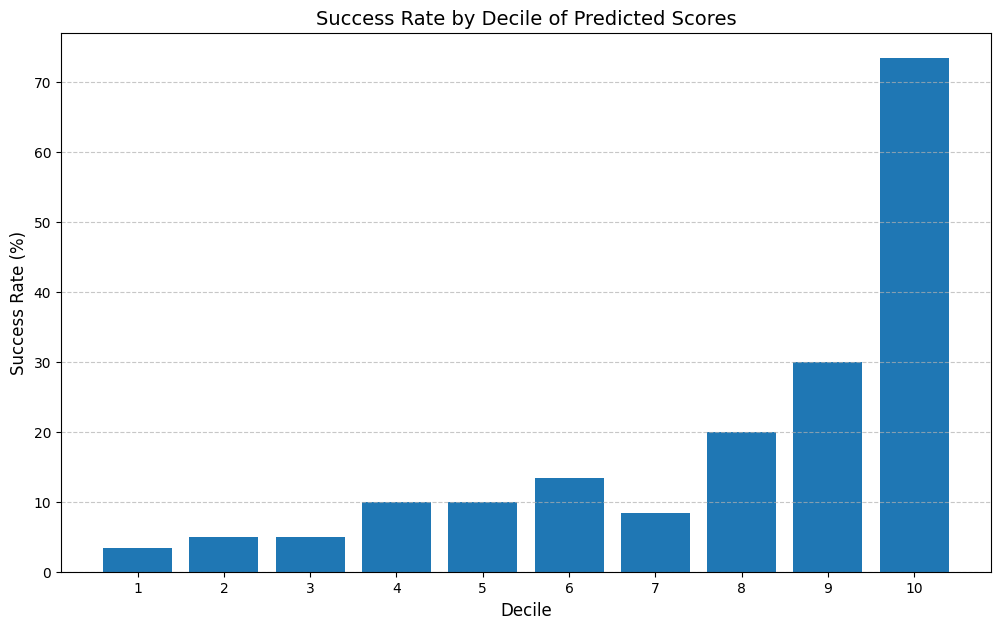

In [ ]:
# Plotting success rate by decile

plt.figure(figsize=(12, 7))
plt.bar(decile_summary["decile"], decile_summary["success_rate"], width=0.8)
plt.title("Success Rate by Decile of Predicted Scores", fontsize=14)
plt.xlabel("Decile", fontsize=12)
plt.ylabel("Success Rate (%)", fontsize=12)
plt.xticks(decile_summary["decile"], fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [ ]:
# SHAP library for feature importance

import shap

shap.initjs()

In [ ]:
shap_exp = shap.TreeExplainer(xgb_hyp, data=shap.maskers.Independent(X_train_sc, max_samples=6000))

In [205]:
shap_exp.expected_value

np.float64(-2.0380650051327622)

In [ ]:
explainer = shap.TreeExplainer(xgb_hyp, X_train_sc)

shap_values_test = explainer.shap_values(X_test_sc, check_additivity=True)

 98%|===================| 1059/1080 [00:39<00:00]        

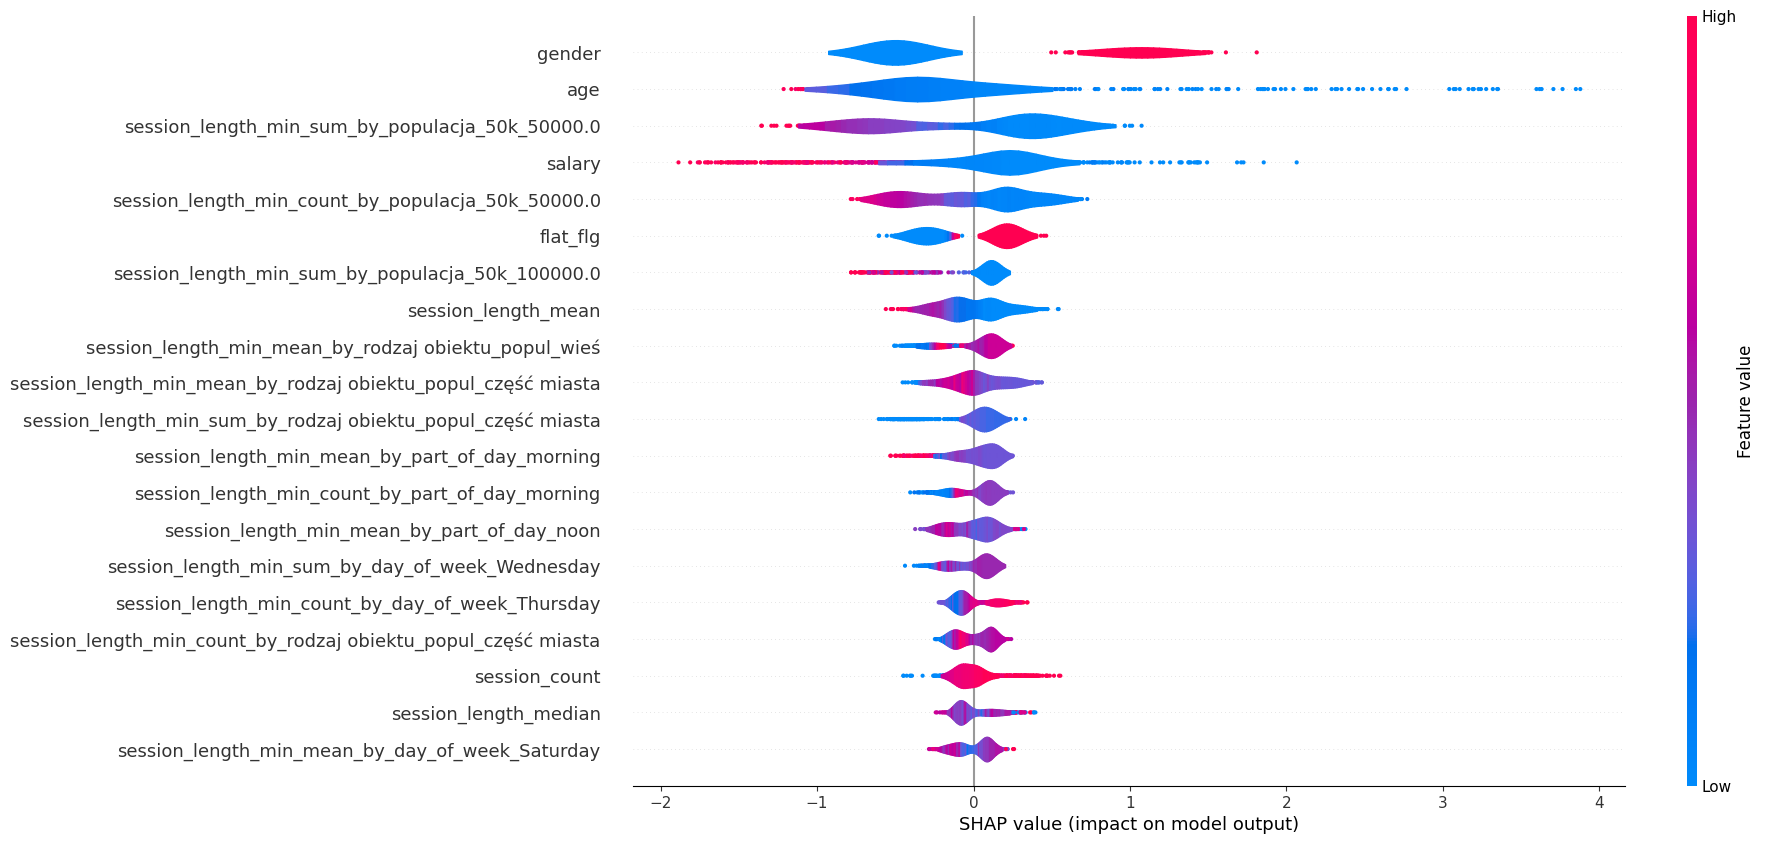

In [ ]:
# decode feature names from pipline transformed structures

feature_names = [f.replace("num__", "").replace("cat__", "") for f in pre.get_feature_names_out()]

shap.plots.violin(shap_values_test, features=X_test_sc, feature_names=feature_names, plot_size=(16, 10))

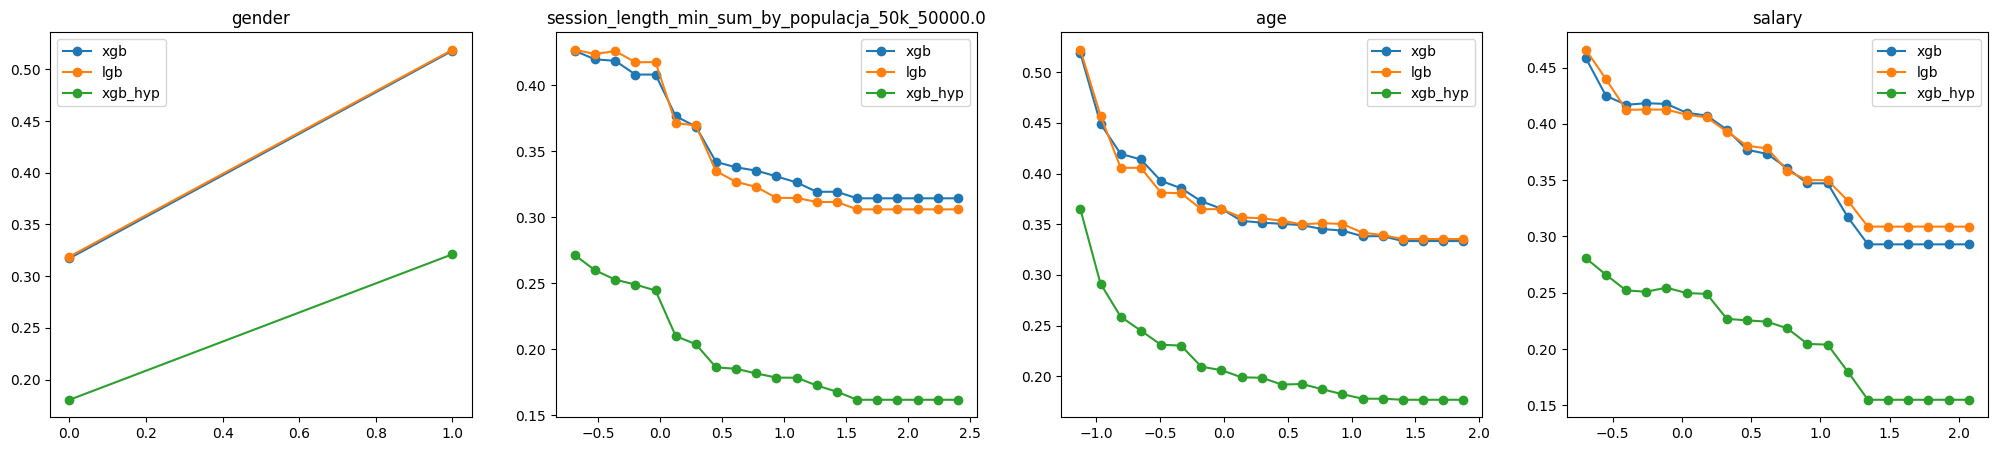

In [ ]:
# Top 4 feature dependences on target variable

from sklearn.inspection import partial_dependence

feature_names = [
    f.replace("num__", "").replace("cat__", "")
    for f in pre.get_feature_names_out()
]
X_pdp = pd.DataFrame(X_train_sc, columns=feature_names)

fig, axes = plt.subplots(ncols=4, figsize=(25, 5))
number = 20

for i, x in enumerate(("gender", "session_length_min_sum_by_populacja_50k_50000.0", "age", "salary")):
    for ai_str, ai in zip(["xgb", "lgb", "xgb_hyp"], [xgb, lgb, xgb_hyp]):
        pdp = partial_dependence(
            ai,
            X_pdp,
            [x],
            grid_resolution=number,
            percentiles=(0.1, 0.99), # checking feature dependencies after excluding extreme percentiles
            kind="average",
            response_method="predict_proba"
        )
        x_values = pdp["grid_values"][0]
        avg = pdp["average"]

        if avg.ndim == 2 and avg.shape[0] == 2:
            y_values = avg[1]
        else:
            y_values = avg.squeeze()
        axes[i].plot(x_values, y_values, marker="o", label=ai_str)

    axes[i].set_title(x)
    axes[i].legend()    

plt.show()